# Run 6: Consolidated Ablation Study (A1–A10, B1–B4, C1–C4)

Single notebook covering all ablation groups from run4 and run5 under a **consistent** setup:
- **17-class shot type mapping** (drive subtypes merged — see `src/config.py`)
- **L2 = 10-dim** features (xy + vel/acc + 4 court-context channels)
- No inter-player edges (court-context features handle relative positioning)

Cascade: **A → A+ → B → B+ → C**

| Group | What varies | Builds on |
|-------|-------------|----------|
| A (A1–A6) | Skeleton repr: L2/L3, dual/single, hitter | — |
| A+ (A7–A10) | Feature enrich: bones, bbox norm | A winner |
| B (B1–B2) | Temporal window: fixed vs variable | A+ winner |
| B+ (B3–B4) | Pooling: attn, max vs mean | A+ + B winner |
| C (C1–C4) | Shuttle fusion: none, graph, cross-attn, A1+xattn ref | A+ + B + B+ winner |

Skip to **§Summary** to view saved results without retraining.

In [3]:
import os, sys, json, time, shutil
from pathlib import Path

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    import zipfile
    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project...')
        with zipfile.ZipFile(DRIVE_ROOT / 'baddiev2_colab.zip') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)
else:
    PROJECT_PATH = Path('..').resolve()
    if not (PROJECT_PATH / 'src').exists():
        PROJECT_PATH = Path('.').resolve()
    DRIVE_ROOT = PROJECT_PATH
    if str(PROJECT_PATH) not in sys.path:
        sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

import src.config as _cfg

if IN_COLAB:
    _cfg.SS_CSV_ROOT        = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV       = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SKELETONS_GDINO = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES        = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.SS_SPLIT_JSON      = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR         = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR        = DRIVE_ROOT / 'results'
    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Shot types ({_cfg.NUM_SHOT_TYPES}): {_cfg.SHOT_TYPES}')
print(f'Project: {PROJECT_PATH}')

Mounted at /content/drive
Extracting project...
Shot types (15): ['net shot', 'return net', 'smash', 'wrist smash', 'lob', 'defensive return lob', 'clear', 'drive', 'drop', 'passive drop', 'push', 'rush', 'cross-court net shot', 'short service', 'long service']
Project: /content/Baddiev2


In [2]:
import json
from pathlib import Path

with open('/content/Baddiev2/datasets_preprocessing/shuttleset_split.json') as f:
    split = json.load(f)

active = set(split['train']) | set(split['held_out'])
skel_root = Path('/content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino')
on_drive = {d.name for d in skel_root.iterdir() if d.is_dir()}

print("Missing from Drive:")
for m in sorted(active - on_drive):
    print(f"  {m}")

Missing from Drive:


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as _Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, accuracy_score

# Imported after config patch — will see patched SHOT_TYPES / NUM_SHOT_TYPES
from src.config import (
    FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, BONE_CHANNELS,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES,
    NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')
print(f'N_CLASSES (NUM_SHOT_TYPES): {NUM_SHOT_TYPES}')
print(f'FEATURE_DIMS: {FEATURE_DIMS}')

ABLATION_DIR = RESULTS_DIR / 'ablations' / 'run7'
MODELS_DIR_R6 = MODELS_DIR / 'run7'
ABLATION_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR_R6.mkdir(parents=True, exist_ok=True)
print(f'Ablation results: {ABLATION_DIR}')

Device: cuda
N_CLASSES (NUM_SHOT_TYPES): 15
FEATURE_DIMS: {'L0': 2, 'L1': 6, 'L2': 10, 'L3': 14}
Ablation results: /content/drive/MyDrive/Baddiev2/results/ablations/run7


In [5]:
import subprocess # Add this import

# Copy data to Colab local SSD for faster I/O (~3x speedup vs Drive)
if IN_COLAB:
    local_skel  = Path('/content/local_skeletons')
    local_shutt = Path('/content/local_shuttles')
    if not local_skel.exists():
        print('Copying skeletons to local SSD...')
        t0 = time.time()
        try:
            # Using rsync for more robust copying from Google Drive
            subprocess.run(['rsync', '-av', '--ignore-existing', str(SS_SKELETONS_GDINO) + '/', str(local_skel)], check=True, capture_output=True)
            print(f'  Done in {time.time()-t0:.0f}s')
        except subprocess.CalledProcessError as e:
            print(f'Error copying skeletons: {e}')
            print(f'Stderr: {e.stderr.decode()}')
            print(f'Stdout: {e.stdout.decode()}')
            raise # Re-raise the exception to clearly indicate failure
    if not local_shutt.exists():
        print('Copying shuttles to local SSD...')
        t0 = time.time()
        try:
            # Using rsync for more robust copying from Google Drive
            subprocess.run(['rsync', '-av', '--ignore-existing', str(SS_SHUTTLES) + '/', str(local_shutt)], check=True, capture_output=True)
            print(f'  Done in {time.time()-t0:.0f}s')
        except subprocess.CalledProcessError as e:
            print(f'Error copying shuttles: {e}')
            print(f'Stderr: {e.stderr.decode()}')
            print(f'Stdout: {e.stdout.decode()}')
            raise # Re-raise the exception to clearly indicate failure
else:
    local_skel  = SS_SKELETONS_GDINO
    local_shutt = SS_SHUTTLES
print(f'Skeletons: {local_skel}')
print(f'Shuttles:  {local_shutt}')

Copying skeletons to local SSD...
  Done in 22s
Copying shuttles to local SSD...
  Done in 64s
Skeletons: /content/local_skeletons
Shuttles:  /content/local_shuttles


In [6]:
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

SHOT_WINDOW  = 32
EPOCHS       = 80
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
N_CLASSES    = NUM_SHOT_TYPES  # 17

with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
TRAIN_MATCHES = set(splits['train']) - set(VAL_MATCH_NAMES)
VAL_MATCHES   = set(VAL_MATCH_NAMES)
TEST_MATCHES  = set(splits['held_out'])
print(f'Train: {len(TRAIN_MATCHES)}  Val: {len(VAL_MATCHES)}  Test: {len(TEST_MATCHES)}')

Train: 17  Val: 2  Test: 2


In [7]:
# ── Load all saved results + reconstruct cascade variables ────────────────
# Run this cell (after cells 1-2) to jump to any section without re-training.
# Safe to run mid-session too — overwrites in-memory vars with saved values.

import json as _j

# Load all result JSONs
_saved = {}
for _p in sorted(ABLATION_DIR.glob('*.json')):
    if _p.stem.startswith('_'): continue
    try:
        _r = _j.load(open(_p))
        _saved[_r['name']] = _r
    except: pass
print(f'Loaded {len(_saved)} results: {sorted(_saved)}')

# Load final config (written after Group C finishes)
_cfg_path = ABLATION_DIR / '_final_config.json'
assert _cfg_path.exists(), f'_final_config.json not found — run through Group C first'
with open(_cfg_path) as _f:
    _fc = _j.load(_f)

# Reconstruct cascade variables from final config
_a_feat       = _fc['feature_layer']
_a_single     = _fc['single_player']
_a_hitter     = _fc['use_hitter']
_use_bones    = _fc['use_bones']
_use_bbox     = _fc['use_bbox_norm']
_variable_win = _fc['variable_window']
_pooling      = _fc['pooling']
_a_in_ch      = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]
# use .get() fallbacks — older _final_config.json may not have these fields
_a_nodes      = _fc.get('num_nodes',   NUM_JOINTS if _a_single else NUM_NODES)
_aplus_in_ch  = _fc.get('in_channels', _a_in_ch + (BONE_CHANNELS if _use_bones else 0))

# Reconstruct group winners from saved results
def _best(names): return max((_saved[n] for n in names if n in _saved), key=lambda r: r['macro_f1'])

best_a     = _best(['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
                    'A5_dual_L2_hitter','A6_dual_L3_hitter'])
best_aplus = _best(['A7_bones_only','A8_bones','A9_bbox_norm','A10_bones_bbox'])
best_b     = _best(['B1_fixed_window','B2_variable_window'])
best_bplus = _best(['B1_fixed_window','B3_attn_pool','B4_max_pool','B5_temporal_transformer'])
best_c     = _saved[_fc['winner_name']]

_d_names = ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']
best_d = _best(_d_names) if any(n in _saved for n in _d_names) else None

print(f'A  winner : {best_a["name"]}  F1={best_a["macro_f1"]:.4f}')
print(f'A+ winner : {best_aplus["name"]}  F1={best_aplus["macro_f1"]:.4f}')
print(f'B  winner : {best_b["name"]}  F1={best_b["macro_f1"]:.4f}')
print(f'B+ winner : {best_bplus["name"]}  F1={best_bplus["macro_f1"]:.4f}')
print(f'C  winner : {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
if best_d: print(f'D  winner : {best_d["name"]}  F1={best_d["macro_f1"]:.4f}')
print(f'\nFinal config: {_fc}')

Loaded 22 results: ['A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3', 'A5_dual_L2_hitter', 'A6_dual_L3_hitter', 'A7_bones_only', 'A8_bones', 'B1_fixed_window', 'B2+_variable_window_pad', 'B2_variable_window', 'B3_attn_pool', 'B4_max_pool', 'B5_temporal_transformer', 'C1_no_shuttle', 'C2_shuttle_graph', 'C3_shuttle_xattn', 'D1_linear', 'D2_mlp1', 'D3_mlp2', 'D4_mlp_bn', 'E1_adaptive_adj']
A  winner : A4_single_L3  F1=0.6171
A+ winner : A7_bones_only  F1=0.6557
B  winner : B1_fixed_window  F1=0.6242
B+ winner : B4_max_pool  F1=0.6373
C  winner : C3_shuttle_xattn  F1=0.6894
D  winner : D1_linear  F1=0.6894

Final config: {'winner_name': 'C3_shuttle_xattn', 'feature_layer': 'L3', 'single_player': True, 'use_hitter': False, 'use_bones': True, 'use_bbox_norm': False, 'variable_window': False, 'pooling': 'max', 'use_shuttle': True, 'shuttle_fusion': 'cross_attn', 'in_channels': 16, 'num_nodes': 17}


In [7]:
import json

def load_result(name):
    path = ABLATION_DIR / f'{name}.json'
    if path.exists():
        with open(path, 'r') as f:
            return json.load(f)
    else:
        print(f'Warning: {path} not found.')
        return None

# Reload results for A8, A9, A10 if they aren't in memory
if 'result_A8' not in locals(): result_A8 = load_result('A8_bones')
if 'result_A9' not in locals(): result_A9 = load_result('A9_bbox_norm')
if 'result_A10' not in locals(): result_A10 = load_result('A10_bones_bbox')

print('Results reloaded from disk.')

Results reloaded from disk.


In [8]:
from collections import Counter

def make_dataset(split_matches, feature_layer='L2', use_hitter=False,
                 use_shuttle=False, shuttle_fusion='graph',
                 variable_window=False, use_bones=False, use_bbox_norm=False):
    ds = ShuttleSetDataset(
        skeleton_dir=local_skel,
        shot_window=SHOT_WINDOW,
        feature_layer=feature_layer,
        load_shot_types=True,
        split=None,
        use_shuttle=use_shuttle,
        shuttle_dir=local_shutt,
        use_hitter=use_hitter,
        variable_window=variable_window,
        shuttle_fusion=shuttle_fusion,
        use_bones=use_bones,
        use_bbox_norm=use_bbox_norm,
    )
    ds.samples = [
        s for s in ds.samples
        if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in split_matches
    ]
    n_valid = sum(1 for s in ds.samples if s.get('shot_type_idx') is not None)
    print(f'  {len(ds.samples)} samples ({n_valid} with labels)')
    return ds


class SinglePlayerWrapper(_Dataset):
    """Extract only the hitter's 17 joints from a dual-player dataset."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label


def collate_fn(batch):
    xs, labels = zip(*[(b[0], b[1]) for b in batch])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0]); labels.append(item[1])
        shuttles.append(item[2] if len(item) == 3 else torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def compute_class_weights(dataset):
    labels = [s.get('shot_type_idx') for s in dataset.samples
              if s.get('shot_type_idx') is not None]
    counts = Counter(labels)
    total  = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        if cls_id < N_CLASSES:
            weights[cls_id] = total / (len(counts) * cnt)
    return weights


def build_encoder(in_channels, num_nodes=NUM_NODES, pooling='mean'):
    single_player = (num_nodes == NUM_JOINTS)
    graph = GraphBuilder(use_inter_player=not single_player, single_player=single_player)
    adj   = graph.build_adjacency().to(device)
    return STGCN(
        in_channels=in_channels,
        num_nodes=num_nodes,
        adjacency=adj,
        num_layers=9,
        base_channels=64,
        embedding_dim=256,
        temporal_kernel=9,
        dropout=0.3,
        pooling=pooling,
    ).to(device)


def _param_count(*modules):
    return sum(p.numel() for m in modules for p in m.parameters())


print('Helpers defined.')

### Why split = None
##the dataset's built-in split= parameter only knows about the JSON's two keys (train/held_out).
##When training needed a 3-way split with val carved out of train, rather than updating the dataset, someone just loaded everything and filtered afterward
##So now you have two parallel filtering mechanisms that do the same thing, one of which is silently ignored.

### Why split = None
##the dataset's built-in split= parameter only knows about the JSON's two keys (train/held_out).
##When training needed a 3-way split with val carved out of train, rather than updating the dataset, someone just loaded everything and filtered afterward
##So now you have two parallel filtering mechanisms that do the same thing, one of which is silently ignored.

Helpers defined.


In [9]:
# E: Adaptive adjacency (2s-AGCN style) — A = A_fixed + B + alpha * C(x)
#   A_fixed : original COCO + inter-player graph
#   B       : learnable per-partition (V,V) mask
#   C(x)    : data-dependent joint similarity = softmax(phi(x)^T theta(x) / sqrt(d))
class AdaptiveSpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, adjacency, embed_d=None):
        super().__init__()
        K, V, _ = adjacency.shape
        self.K, self.V = K, V
        self.conv  = nn.Conv2d(in_channels, out_channels * K, 1)
        self.register_buffer("A_fixed", adjacency.clone())
        self.B     = nn.Parameter(torch.zeros(K, V, V))
        d = embed_d or max(in_channels // 4, 8)
        self.d     = d
        self.phi   = nn.Conv2d(in_channels, d * K, 1)
        self.theta = nn.Conv2d(in_channels, d * K, 1)
        self.alpha = nn.Parameter(torch.zeros(K))   # gate C(x), starts at 0 -> reduces to fixed graph at init

    def forward(self, x):
        B, _, T, V = x.shape
        h = self.conv(x).view(B, self.K, -1, T, V)                       # (B,K,C',T,V)
        phi = self.phi(x).view(B, self.K, self.d, T, V).mean(dim=3)      # (B,K,d,V)
        the = self.theta(x).view(B, self.K, self.d, T, V).mean(dim=3)    # (B,K,d,V)
        C_dyn = torch.softmax(torch.einsum("bkdi,bkdj->bkij", phi, the) / (self.d ** 0.5), dim=-1)
        out = x.new_zeros(B, h.shape[2], T, V)
        for k in range(self.K):
            A_k = self.A_fixed[k] + self.B[k] + self.alpha[k] * C_dyn[:, k]   # (B,V,V) via broadcast
            out = out + torch.einsum("bctv,bvw->bctw", h[:, k], A_k)
        return out


def build_encoder_adaptive(in_channels, num_nodes=NUM_NODES, pooling='mean'):
    enc = build_encoder(in_channels, num_nodes=num_nodes, pooling=pooling)
    for block in enc.layers:
        old = block.spatial
        c_in  = old.conv.in_channels
        c_out = old.conv.out_channels // old.num_subsets
        block.spatial = AdaptiveSpatialGraphConv(c_in, c_out, old.A).to(device)
    return enc

print('Adaptive encoder helper defined.')


Adaptive encoder helper defined.


In [10]:
def evaluate(encoder, head, ds, cross_attn=None):
    cfn    = collate_fn_shuttle if cross_attn else collate_fn
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True, collate_fn=cfn)
    encoder.eval(); head.eval()
    if cross_attn: cross_attn.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            xb, yb = batch[0], batch[1]
            valid  = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn:
                emb = cross_attn(emb, batch[2][valid].to(device))
            all_logits.append(head(emb).cpu())
            all_labels.append(yb[valid])

    if not all_logits:
        return 0.0, 0.0, np.array([]), np.array([]), {}

    logits = torch.cat(all_logits)
    y_true = torch.cat(all_labels).numpy()
    y_pred = logits.argmax(1).numpy()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    topk = {}
    for k in [3, 5]:
        if logits.shape[1] >= k:
            correct = logits.topk(k, 1).indices.eq(torch.tensor(y_true).unsqueeze(1)).any(1)
            topk[f'top{k}_acc'] = correct.float().mean().item()
    return macro_f1, accuracy, y_true, y_pred, topk


def train_and_evaluate(name, train_ds, val_ds, test_ds, encoder, head,
                       cross_attn=None, epochs=EPOCHS):
    cfn          = collate_fn_shuttle if cross_attn else collate_fn
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn)
    criterion    = nn.CrossEntropyLoss(weight=compute_class_weights(train_ds).to(device))
    params       = list(encoder.parameters()) + list(head.parameters())
    if cross_attn: params += list(cross_attn.parameters())
    optimizer    = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1, no_improve, best_state = -1.0, 0, None
    history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(epochs):
        encoder.train(); head.train()
        if cross_attn: cross_attn.train()
        epoch_loss, n_batches = 0.0, 0

        for batch in tqdm(train_loader, desc=f'[{name}] {epoch+1}/{epochs}', leave=False):
            xb, yb = batch[0], batch[1]
            valid  = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn: emb = cross_attn(emb, batch[2][valid].to(device))
            loss = criterion(head(emb), yb[valid].to(device))
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()
            epoch_loss += loss.item(); n_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        val_f1, val_acc, _, _, _ = evaluate(encoder, head, val_ds, cross_attn)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | loss {avg_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1; no_improve = 0
            best_state = {
                'enc':  {k: v.cpu().clone() for k, v in encoder.state_dict().items()},
                'head': {k: v.cpu().clone() for k, v in head.state_dict().items()},
            }
            if cross_attn:
                best_state['ca'] = {k: v.cpu().clone() for k, v in cross_attn.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stop epoch {epoch+1} (best val F1: {best_val_f1:.4f})')
                break

    if best_state:
        encoder.load_state_dict(best_state['enc'])
        head.load_state_dict(best_state['head'])
        if cross_attn and 'ca' in best_state:
            cross_attn.load_state_dict(best_state['ca'])

    macro_f1, accuracy, y_true, y_pred, topk = evaluate(encoder, head, test_ds, cross_attn)
    elapsed = time.time() - t0

    present = sorted(set(y_true) | set(y_pred))
    names   = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'cls_{i}' for i in present]
    print(f'\n  === {name} ===')
    print(f'  Acc={accuracy:.4f}  F1={macro_f1:.4f}  '
          f'Top3={topk.get("top3_acc",0):.4f}  Top5={topk.get("top5_acc",0):.4f}  '
          f'Epochs={len(history["train_loss"])}  Time={elapsed:.0f}s')
    print(classification_report(y_true, y_pred, labels=present, target_names=names, zero_division=0))

    result = {
        'name': name,
        'accuracy':    round(accuracy,  4),
        'macro_f1':    round(macro_f1,  4),
        'top3_acc':    round(topk.get('top3_acc', 0), 4),
        'top5_acc':    round(topk.get('top5_acc', 0), 4),
        'best_val_f1': round(best_val_f1, 4),
        'stopped_epoch': len(history['train_loss']),
        'train_time_s':  round(elapsed, 1),
        'n_train': len(train_ds.samples),
        'n_val':   len(val_ds.samples),
        'n_test':  len(test_ds.samples),
        'history': history,
        'per_class': classification_report(
            y_true, y_pred, labels=present, target_names=names,
            zero_division=0, output_dict=True),
    }
    with open(ABLATION_DIR / f'{name}.json', 'w') as f:
        json.dump(result, f, indent=2)
    ckpt = {'enc': encoder.state_dict(), 'head': head.state_dict(),
            'name': name, 'accuracy': accuracy, 'macro_f1': macro_f1}
    if cross_attn: ckpt['ca'] = cross_attn.state_dict()
    torch.save(ckpt, MODELS_DIR_R6 / f'{name}.pt')
    print(f'  Saved: {ABLATION_DIR}/{name}.json  |  {MODELS_DIR_R6}/{name}.pt')
    return result

print('train_and_evaluate defined.')

train_and_evaluate defined.


## §A — Group A: Skeleton Representation

Vary feature layer (L2 vs L3), player count (dual 34-node vs single 17-node), and hitter channel.
No shuttle. Fixed T=32 window. Mean pooling.

| # | Config | In-ch | Nodes |
|---|--------|-------|-------|
| A1 | Dual L2 | 10 | 34 |
| A2 | Dual L3 | 14 | 34 |
| A3 | Single L2 | 10 | 17 |
| A4 | Single L3 | 14 | 17 |
| A5 | Dual L2 + hitter | 11 | 34 |
| A6 | Dual L3 + hitter | 15 | 34 |

In [ ]:
print('A1: Dual-player L2 (baseline)')
train_A1 = make_dataset(TRAIN_MATCHES, feature_layer='L2')
val_A1   = make_dataset(VAL_MATCHES,   feature_layer='L2')
test_A1  = make_dataset(TEST_MATCHES,  feature_layer='L2')

in_ch_A1   = FEATURE_DIMS['L2']  # 10
encoder_A1 = build_encoder(in_ch_A1, num_nodes=NUM_NODES)
head_A1    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A1, head_A1):,}')

result_A1 = train_and_evaluate('A1_dual_L2', train_A1, val_A1, test_A1, encoder_A1, head_A1)

A1: Dual-player L2 (baseline)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,378


  Epoch  10/80 | loss 0.6158 | val_f1 0.4797


  Epoch  20/80 | loss 0.2747 | val_f1 0.5618


  Epoch  30/80 | loss 0.1129 | val_f1 0.5259
  Early stop epoch 30 (best val F1: 0.5618)

  === A1_dual_L2 ===
  Acc=0.6435  F1=0.5949  Top3=0.9096  Top5=0.9594  Epochs=30  Time=441s
                      precision    recall  f1-score   support

            net shot       0.83      0.82      0.83       296
          return net       0.73      0.63      0.68       163
               smash       0.63      0.55      0.59       107
         wrist smash       0.37      0.33      0.35        75
                 lob       0.43      0.89      0.58       137
defensive return lob       0.31      0.62      0.42         8
               clear       0.88      0.78      0.83       129
               drive       0.62      0.38      0.47       106
                drop       0.34      0.66      0.45        61
        passive drop       0.68      0.49      0.57        88
                push       0.78      0.34      0.47       226
                rush       0.55      0.35      0.43        31
cross-cour

In [ ]:
print('A2: Dual-player L3')
train_A2 = make_dataset(TRAIN_MATCHES, feature_layer='L3')
val_A2   = make_dataset(VAL_MATCHES,   feature_layer='L3')
test_A2  = make_dataset(TEST_MATCHES,  feature_layer='L3')

in_ch_A2   = FEATURE_DIMS['L3']  # 14
encoder_A2 = build_encoder(in_ch_A2, num_nodes=NUM_NODES)
head_A2    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A2, head_A2):,}')

result_A2 = train_and_evaluate('A2_dual_L3', train_A2, val_A2, test_A2, encoder_A2, head_A2)

A2: Dual-player L3
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,674


  Epoch  10/80 | loss 0.5993 | val_f1 0.5170


  Epoch  20/80 | loss 0.2652 | val_f1 0.5405


  Early stop epoch 24 (best val F1: 0.5533)

  === A2_dual_L3 ===
  Acc=0.6361  F1=0.5660  Top3=0.9035  Top5=0.9600  Epochs=24  Time=436s
                      precision    recall  f1-score   support

            net shot       0.83      0.81      0.82       296
          return net       0.76      0.64      0.70       163
               smash       0.59      0.35      0.44       107
         wrist smash       0.32      0.37      0.34        75
                 lob       0.40      0.91      0.55       137
defensive return lob       0.12      0.25      0.17         8
               clear       0.87      0.80      0.83       129
               drive       0.76      0.42      0.54       106
                drop       0.35      0.62      0.45        61
        passive drop       0.63      0.70      0.67        88
                push       0.72      0.31      0.44       226
                rush       0.39      0.23      0.29        31
cross-court net shot       0.58      0.65      0.61    

In [ ]:
print('A3: Single-player L2 (hitter only)')
train_A3 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, feature_layer='L2'))
val_A3   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   feature_layer='L2'))
test_A3  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  feature_layer='L2'))

in_ch_A3   = FEATURE_DIMS['L2']  # 10
encoder_A3 = build_encoder(in_ch_A3, num_nodes=NUM_JOINTS)
head_A3    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A3, head_A3):,}')

result_A3 = train_and_evaluate('A3_single_L2', train_A3, val_A3, test_A3, encoder_A3, head_A3)

A3: Single-player L2 (hitter only)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,038


KeyboardInterrupt: 

In [ ]:
print('A4: Single-player L3')
train_A4 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, feature_layer='L3'))
val_A4   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   feature_layer='L3'))
test_A4  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  feature_layer='L3'))

in_ch_A4   = FEATURE_DIMS['L3']  # 14
encoder_A4 = build_encoder(in_ch_A4, num_nodes=NUM_JOINTS)
head_A4    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A4, head_A4):,}')

result_A4 = train_and_evaluate('A4_single_L3', train_A4, val_A4, test_A4, encoder_A4, head_A4)

A4: Single-player L3
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198


  Epoch  10/80 | loss 0.7008 | val_f1 0.5156


  Epoch  20/80 | loss 0.3908 | val_f1 0.5267


  Epoch  30/80 | loss 0.1900 | val_f1 0.5231


  Early stop epoch 38 (best val F1: 0.5636)

  === A4_single_L3 ===
  Acc=0.6896  F1=0.6171  Top3=0.9318  Top5=0.9693  Epochs=38  Time=666s
                      precision    recall  f1-score   support

            net shot       0.88      0.80      0.84       296
          return net       0.79      0.66      0.72       163
               smash       0.61      0.61      0.61       107
         wrist smash       0.36      0.39      0.37        75
                 lob       0.53      0.82      0.64       137
defensive return lob       0.20      0.38      0.26         8
               clear       0.91      0.87      0.89       129
               drive       0.61      0.48      0.54       106
                drop       0.48      0.66      0.56        61
        passive drop       0.70      0.61      0.65        88
                push       0.70      0.50      0.58       226
                rush       0.59      0.65      0.62        31
cross-court net shot       0.45      0.78      0.57  

In [ ]:
print('A5: Dual-player L2 + hitter channel')
train_A5 = make_dataset(TRAIN_MATCHES, feature_layer='L2', use_hitter=True)
val_A5   = make_dataset(VAL_MATCHES,   feature_layer='L2', use_hitter=True)
test_A5  = make_dataset(TEST_MATCHES,  feature_layer='L2', use_hitter=True)

in_ch_A5   = FEATURE_DIMS_WITH_HITTER['L2']  # 11
encoder_A5 = build_encoder(in_ch_A5, num_nodes=NUM_NODES)
head_A5    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A5, head_A5):,}')

result_A5 = train_and_evaluate('A5_dual_L2_hitter', train_A5, val_A5, test_A5, encoder_A5, head_A5)

A5: Dual-player L2 + hitter channel
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,702


  Epoch  10/80 | loss 0.6021 | val_f1 0.5209


  Epoch  20/80 | loss 0.2711 | val_f1 0.5456


  Epoch  30/80 | loss 0.1044 | val_f1 0.5255


  Early stop epoch 37 (best val F1: 0.5523)

  === A5_dual_L2_hitter ===
  Acc=0.6558  F1=0.5832  Top3=0.9103  Top5=0.9644  Epochs=37  Time=569s
                      precision    recall  f1-score   support

            net shot       0.80      0.86      0.83       296
          return net       0.74      0.71      0.72       163
               smash       0.60      0.55      0.58       107
         wrist smash       0.34      0.43      0.38        75
                 lob       0.47      0.83      0.60       137
defensive return lob       0.11      0.38      0.17         8
               clear       0.88      0.78      0.83       129
               drive       0.65      0.33      0.44       106
                drop       0.41      0.69      0.52        61
        passive drop       0.77      0.50      0.61        88
                push       0.69      0.38      0.49       226
                rush       0.50      0.52      0.51        31
cross-court net shot       0.54      0.52      0

In [ ]:
print('A6: Dual-player L3 + hitter channel')
train_A6 = make_dataset(TRAIN_MATCHES, feature_layer='L3', use_hitter=True)
val_A6   = make_dataset(VAL_MATCHES,   feature_layer='L3', use_hitter=True)
test_A6  = make_dataset(TEST_MATCHES,  feature_layer='L3', use_hitter=True)

in_ch_A6   = FEATURE_DIMS_WITH_HITTER['L3']  # 15
encoder_A6 = build_encoder(in_ch_A6, num_nodes=NUM_NODES)
head_A6    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A6, head_A6):,}')

result_A6 = train_and_evaluate('A6_dual_L3_hitter', train_A6, val_A6, test_A6, encoder_A6, head_A6)

A6: Dual-player L3 + hitter channel
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,998


  Epoch  10/80 | loss 0.6012 | val_f1 0.5368


  Epoch  20/80 | loss 0.2902 | val_f1 0.5259


  Epoch  30/80 | loss 0.1105 | val_f1 0.5555


  Early stop epoch 37 (best val F1: 0.5639)

  === A6_dual_L3_hitter ===
  Acc=0.6411  F1=0.5671  Top3=0.9140  Top5=0.9619  Epochs=37  Time=684s
                      precision    recall  f1-score   support

            net shot       0.81      0.88      0.84       296
          return net       0.72      0.70      0.71       163
               smash       0.55      0.69      0.61       107
         wrist smash       0.39      0.12      0.18        75
                 lob       0.41      0.82      0.54       137
defensive return lob       0.14      0.38      0.20         8
               clear       0.87      0.83      0.85       129
               drive       0.67      0.35      0.46       106
                drop       0.37      0.69      0.48        61
        passive drop       0.73      0.49      0.59        88
                push       0.64      0.30      0.41       226
                rush       0.38      0.48      0.43        31
cross-court net shot       0.55      0.49      0

## §A+ — Group A+: Feature Representation

Bone vectors (limb direction/length) and bbox normalization (scale invariance),
tested on top of the A winner. Baseline is the A winner result carried forward.

| # | Config | In-ch | Notes |
|---|--------|-------|-------|
| A7 | Bones only | 2 | limb direction/length, no joint positions |
| A8 | A winner + bones | +2 | joints + structural shape (early fusion) |
| A9 | A winner + bbox norm | +0 | scale-invariant joint positions |
| A10 | A winner + bones + bbox | +2 | both |

In [ ]:
print('A7: Bones only (no joint positions) — 2-dim per node')
# Build L0+bones dataset (4-dim), then strip the L0 xy leaving only bone vectors

class BonesOnlyWrapper(_Dataset):
    """Drops the base joint features, returns only the appended bone channels."""
    def __init__(self, ds, base_ch):
        self.ds = ds
        self.samples = ds.samples
        self.base_ch = base_ch
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x = item[0][self.base_ch:]  # (C, T, V) → drop first base_ch channels
        return (x,) + item[1:]

_mk7 = dict(feature_layer='L0', use_hitter=False, use_bones=True)
_base_ch = FEATURE_DIMS['L0']  # 2 (xy to discard)

train_A7 = BonesOnlyWrapper(make_dataset(TRAIN_MATCHES, **_mk7), _base_ch)
val_A7   = BonesOnlyWrapper(make_dataset(VAL_MATCHES,   **_mk7), _base_ch)
test_A7  = BonesOnlyWrapper(make_dataset(TEST_MATCHES,  **_mk7), _base_ch)

in_ch_A7   = BONE_CHANNELS  # 2
encoder_A7 = build_encoder(in_ch_A7, num_nodes=NUM_NODES)
head_A7    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A7, head_A7):,}  in_ch={in_ch_A7}')

result_A7 = train_and_evaluate('A7_bones_only', train_A7, val_A7, test_A7, encoder_A7, head_A7)

A7: Bones only (no joint positions) — 2-dim per node
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,084,786  in_ch=2


  Epoch  10/80 | loss 0.6704 | val_f1 0.5415


  Epoch  20/80 | loss 0.3741 | val_f1 0.5906


  Epoch  30/80 | loss 0.2009 | val_f1 0.5669
  Early stop epoch 30 (best val F1: 0.5906)

  === A7_bones_only ===
  Acc=0.7050  F1=0.6557  Top3=0.9392  Top5=0.9785  Epochs=30  Time=389s
                      precision    recall  f1-score   support

            net shot       0.79      0.90      0.84       296
          return net       0.91      0.52      0.66       163
               smash       0.69      0.60      0.64       107
         wrist smash       0.46      0.40      0.43        75
                 lob       0.50      0.88      0.64       137
defensive return lob       0.31      0.50      0.38         8
               clear       0.84      0.94      0.89       129
               drive       0.60      0.50      0.54       106
                drop       0.52      0.75      0.61        61
        passive drop       0.75      0.62      0.68        88
                push       0.71      0.54      0.61       226
                rush       0.45      0.42      0.43        31
cross-c

In [ ]:
print('A8: A3_single_L2 + bone vectors')
print(f'Using A  config: feature_layer={_a_feat}, single_player={_a_single}, use_hitter={_a_hitter}')
_mk8 = dict(feature_layer=_a_feat, use_hitter=_a_hitter, use_bones=True)
train_A8 = (SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_mk8)) if _a_single
            else make_dataset(TRAIN_MATCHES, **_mk8))
val_A8   = (SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_mk8)) if _a_single
            else make_dataset(VAL_MATCHES,   **_mk8))
test_A8  = (SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_mk8)) if _a_single
            else make_dataset(TEST_MATCHES,  **_mk8))

in_ch_A8   = _a_in_ch + BONE_CHANNELS  # +2
encoder_A8 = build_encoder(in_ch_A8, num_nodes=_a_nodes)
head_A8    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A8, head_A8):,}  in_ch={in_ch_A8}')

result_A8 = train_and_evaluate('A8_bones', train_A8, val_A8, test_A8, encoder_A8, head_A8)

A8: A winner + bone vectors
Using A winner config: feature_layer=L2, single_player=True, use_hitter=False
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,618  in_ch=12


  Epoch  10/80 | loss 0.6679 | val_f1 0.5309


  Epoch  20/80 | loss 0.4056 | val_f1 0.5775


  Epoch  30/80 | loss 0.2239 | val_f1 0.5552
  Early stop epoch 30 (best val F1: 0.5775)

  === A8_bones ===
  Acc=0.7001  F1=0.6242  Top3=0.9447  Top5=0.9828  Epochs=30  Time=514s
                      precision    recall  f1-score   support

            net shot       0.82      0.86      0.84       296
          return net       0.80      0.63      0.71       163
               smash       0.63      0.52      0.57       107
         wrist smash       0.37      0.33      0.35        75
                 lob       0.55      0.77      0.64       137
defensive return lob       0.29      0.50      0.36         8
               clear       0.96      0.82      0.89       129
               drive       0.61      0.56      0.58       106
                drop       0.46      0.62      0.53        61
        passive drop       0.64      0.83      0.72        88
                push       0.77      0.54      0.64       226
                rush       0.56      0.61      0.58        31
cross-court 

In [ ]:
# ------------------------------------------------------------------
# Group A + A+ summary. Picks A+ winner; sets foundation config that
# E1 (and B/C/D) will build on.
#
# Note: A7 (bones-only, dual) is a different feature track from A1–A6,
# so it's reported but not eligible to set the foundation. To allow it,
# add A7 to _eligible below — but then B/C/D need a BonesOnlyWrapper
# branch.
#
# Caveat: A8's config is reconstructed from the current A1–A6 winner.
# If A8 was originally trained when a different A config was winning,
# its on-disk metrics may not match this reconstruction — re-run A8
# whenever the A winner changes.
# ------------------------------------------------------------------
_A_base_names = ['A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3',
                 'A5_dual_L2_hitter', 'A6_dual_L3_hitter']
_A_plus_names = ['A7_bones_only', 'A8_bones']

def _load(name):
    p = ABLATION_DIR / f'{name}.json'
    return json.load(open(p)) if p.exists() else None

# Static configs (A8 filled in dynamically below from A1–A6 winner)
_CONFIGS_A = {
    'A1_dual_L2':        dict(feat='L2', single=False, hitter=False, bones=False, bbox=False, bones_only=False),
    'A2_dual_L3':        dict(feat='L3', single=False, hitter=False, bones=False, bbox=False, bones_only=False),
    'A3_single_L2':      dict(feat='L2', single=True,  hitter=False, bones=False, bbox=False, bones_only=False),
    'A4_single_L3':      dict(feat='L3', single=True,  hitter=False, bones=False, bbox=False, bones_only=False),
    'A5_dual_L2_hitter': dict(feat='L2', single=False, hitter=True,  bones=False, bbox=False, bones_only=False),
    'A6_dual_L3_hitter': dict(feat='L3', single=False, hitter=True,  bones=False, bbox=False, bones_only=False),
    'A7_bones_only':     dict(feat=None, single=False, hitter=False, bones=True,  bbox=False, bones_only=True),
}

# Load results
_A_base_loaded = [r for r in (_load(n) for n in _A_base_names) if r]
_A_plus_loaded = [r for r in (_load(n) for n in _A_plus_names) if r]
_A_all         = _A_base_loaded + _A_plus_loaded

# A1–A6 winner drives A8's config
best_a = max(_A_base_loaded, key=lambda r: r['macro_f1'])
_a8_cfg = dict(_CONFIGS_A[best_a['name']])
_a8_cfg['bones'] = True
_CONFIGS_A['A8_bones'] = _a8_cfg

# A+ winner: best of {A1–A6 winner, A8}. A7 reported only.
_a8_result = next((r for r in _A_plus_loaded if r['name'] == 'A8_bones'), None)
_eligible  = [best_a] + ([_a8_result] if _a8_result else [])
best_aplus = max(_eligible, key=lambda r: r['macro_f1'])
_cfg = _CONFIGS_A[best_aplus['name']]

_a_feat      = _cfg['feat']
_a_single    = _cfg['single']
_a_hitter    = _cfg['hitter']
_use_bones   = _cfg['bones']
_use_bbox    = _cfg['bbox']
_a_nodes     = NUM_JOINTS if _a_single else NUM_NODES
_a_in_ch     = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]
_aplus_in_ch = _a_in_ch + (BONE_CHANNELS if _use_bones else 0)

print('='*70)
print('Group A & A+ Results')
print('='*70)
print(f'{"Name":<25} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in sorted(_A_all, key=lambda x: x['macro_f1'], reverse=True):
    flag = '  (exploratory)' if r['name'] == 'A7_bones_only' else ''
    print(f'{r["name"]:<25} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}{flag}')

print(f'\nA1–A6 winner: {best_a["name"]}      F1={best_a["macro_f1"]:.4f}')
print(f'A+ winner   : {best_aplus["name"]}  F1={best_aplus["macro_f1"]:.4f}')
print(f'  feat={_a_feat}, single={_a_single}, hitter={_a_hitter}, '
      f'bones={_use_bones}, bbox={_use_bbox}')
print(f'  _a_in_ch={_a_in_ch}, _aplus_in_ch={_aplus_in_ch}, _a_nodes={_a_nodes}')



Group A & A+ Results
Name                           Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
A7_bones_only               0.7050   0.6557   0.9392   0.9785       30  (exploratory)
A8_bones                    0.7001   0.6242   0.9447   0.9828       30
A4_single_L3                0.6896   0.6171   0.9318   0.9693       38
A1_dual_L2                  0.6435   0.5949   0.9096   0.9594       30
A5_dual_L2_hitter           0.6558   0.5832   0.9103   0.9644       37
A6_dual_L3_hitter           0.6411   0.5671   0.9140   0.9619       37
A2_dual_L3                  0.6361   0.5660   0.9035   0.9600       24
A3_single_L2                0.6288   0.5523   0.9256   0.9791       17

A1–A6 winner: A4_single_L3      F1=0.6171
A+ winner   : A8_bones  F1=0.6242
  feat=L3, single=True, hitter=False, bones=True, bbox=False
  _a_in_ch=14, _aplus_in_ch=16, _a_nodes=17


## §B — Additional Group E - Encoder Attention (Adaptive Adjacency) :


In [ ]:
print(f'E1: Adaptive adjacency on A+ winner config '
      f'(feat={_a_feat}, single={_a_single}, bones={_use_bones})')

_e1_kw = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
              use_bones=_use_bones, use_bbox_norm=_use_bbox)

train_E1 = make_dataset(TRAIN_MATCHES, **_e1_kw)
val_E1   = make_dataset(VAL_MATCHES,   **_e1_kw)
test_E1  = make_dataset(TEST_MATCHES,  **_e1_kw)

if _a_single:
    train_E1 = SinglePlayerWrapper(train_E1)
    val_E1   = SinglePlayerWrapper(val_E1)
    test_E1  = SinglePlayerWrapper(test_E1)

encoder_E1 = build_encoder_adaptive(_aplus_in_ch, num_nodes=_a_nodes)
head_E1    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_E1, head_E1):,}')

result_E1 = train_and_evaluate('E1_adaptive_adj',
                               train_E1, val_E1, test_E1,
                               encoder_E1, head_E1)



E1: Adaptive adjacency on A+ winner config (feat=L3, single=True, bones=True)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,387,797


  Epoch  10/80 | loss 0.6469 | val_f1 0.5627


  Epoch  20/80 | loss 0.3421 | val_f1 0.5508


  Epoch  30/80 | loss 0.1641 | val_f1 0.5771


  Early stop epoch 35 (best val F1: 0.5918)

  === E1_adaptive_adj ===
  Acc=0.6865  F1=0.6200  Top3=0.9422  Top5=0.9809  Epochs=35  Time=822s
                      precision    recall  f1-score   support

            net shot       0.87      0.83      0.85       296
          return net       0.74      0.74      0.74       163
               smash       0.66      0.65      0.66       107
         wrist smash       0.44      0.23      0.30        75
                 lob       0.48      0.85      0.61       137
defensive return lob       0.22      0.62      0.32         8
               clear       0.84      0.88      0.86       129
               drive       0.57      0.40      0.47       106
                drop       0.43      0.72      0.54        61
        passive drop       0.76      0.57      0.65        88
                push       0.68      0.46      0.55       226
                rush       0.56      0.81      0.66        31
cross-court net shot       0.61      0.54      0.5

In [ ]:
import torch
for name, p in encoder_E1.named_parameters():
    if any(k in name for k in ('alpha', 'B_mask', '.B', 'PA')):  # match your code's naming
        v = p.detach()
        print(f'{name:40s}  shape={tuple(v.shape)}  '
              f'mean={v.mean().item():+.4f}  std={v.std().item():.4f}  '
              f'|max|={v.abs().max().item():.4f}')


layers.0.spatial.B                        shape=(3, 17, 17)  mean=+0.0061  std=0.0706  |max|=0.2651
layers.0.spatial.alpha                    shape=(3,)  mean=+0.0355  std=0.0276  |max|=0.0662
layers.1.spatial.B                        shape=(3, 17, 17)  mean=-0.0031  std=0.0783  |max|=0.2520
layers.1.spatial.alpha                    shape=(3,)  mean=-0.0888  std=0.0048  |max|=0.0937
layers.2.spatial.B                        shape=(3, 17, 17)  mean=-0.0061  std=0.0883  |max|=0.3191
layers.2.spatial.alpha                    shape=(3,)  mean=+0.0733  std=0.0571  |max|=0.1066
layers.3.spatial.B                        shape=(3, 17, 17)  mean=-0.0249  std=0.0871  |max|=0.3321
layers.3.spatial.alpha                    shape=(3,)  mean=-0.0118  std=0.0460  |max|=0.0553
layers.4.spatial.B                        shape=(3, 17, 17)  mean=+0.0017  std=0.0797  |max|=0.2584
layers.4.spatial.alpha                    shape=(3,)  mean=+0.0315  std=0.0290  |max|=0.0645
layers.5.spatial.B                 

In [ ]:
# ------------------------------------------------------------------
# Foundation summary: pick foundation from {A+ winner, E1}.
# A7 is exploratory and NOT eligible (handled the same way as in the
# A/A+ summary cell). Falls through to A8/E1 if A7 had the highest raw F1.
# ------------------------------------------------------------------
_E_loaded   = [r for r in (_load(n) for n in ['E1_adaptive_adj']) if r]
result_E1_d = _E_loaded[0] if _E_loaded else None

# Pool: A+ winner (already excludes A7) + E1 if present
_foundation_pool = [best_aplus] + ([result_E1_d] if result_E1_d else [])
_baseline        = max(_foundation_pool, key=lambda r: r['macro_f1'])
_use_adaptive    = _baseline['name'] == 'E1_adaptive_adj'

# Sanity check: E1 should have trained on the current best_aplus config.
# If best_aplus changed since E1 ran, the comparison is stale.
if result_E1_d is not None and best_aplus['name'] != 'A8_bones' and _use_bones:
    print('[warn] E1 may have trained on a different foundation than the current best_aplus.')
    print(f'       best_aplus={best_aplus["name"]} but _use_bones={_use_bones} suggests A8.')

print('='*70)
print('FOUNDATION (A / A+ / E)')
print('='*70)
print(f'{"Name":<25} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in sorted(_A_all + _E_loaded, key=lambda x: x['macro_f1'], reverse=True):
    flag = '  (exploratory)' if r['name'] == 'A7_bones_only' else ''
    print(f'{r["name"]:<25} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}{flag}')

print(f'\nFoundation winner: {_baseline["name"]}  F1={_baseline["macro_f1"]:.4f}')
print(f'  feat={_a_feat}, single={_a_single}, hitter={_a_hitter}, '
      f'bones={_use_bones}, bbox={_use_bbox}, adaptive={_use_adaptive}')
print(f'  _a_in_ch={_a_in_ch}, _aplus_in_ch={_aplus_in_ch}, _a_nodes={_a_nodes}')



FOUNDATION (A / A+ / E)
Name                           Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
A7_bones_only               0.7050   0.6557   0.9392   0.9785       30  (exploratory)
A8_bones                    0.7001   0.6242   0.9447   0.9828       30
E1_adaptive_adj             0.6865   0.6200   0.9422   0.9809       35
A4_single_L3                0.6896   0.6171   0.9318   0.9693       38
A1_dual_L2                  0.6435   0.5949   0.9096   0.9594       30
A5_dual_L2_hitter           0.6558   0.5832   0.9103   0.9644       37
A6_dual_L3_hitter           0.6411   0.5671   0.9140   0.9619       37
A2_dual_L3                  0.6361   0.5660   0.9035   0.9600       24
A3_single_L2                0.6288   0.5523   0.9256   0.9791       17

Foundation winner: A8_bones  F1=0.6242
  feat=L3, single=True, hitter=False, bones=True, bbox=False, adaptive=False
  _a_in_ch=14, _aplus_in_ch=16, _a_nodes=17


## §B — Group B: Temporal Window

Fixed T=32 vs variable window (hit-frame boundaries). Uses A+ winner config.

| # | Window | Description |
|---|--------|-------------|
| B1 | Fixed T=32 | A+ winner repeat (cascade baseline) |
| B2 | Variable | Clip from previous to next hit frame |

In [ ]:
# B1: fixed T=32, same config as overall baseline (A/A+/E winner).
# Reuse metrics, no retrain.
result_B1 = _baseline.copy()
result_B1['name'] = 'B1_fixed_window'
with open(ABLATION_DIR / 'B1_fixed_window.json', 'w') as f:
    json.dump(result_B1, f, indent=2)
print(f'B1_fixed_window <- {_baseline["name"]}  F1={result_B1["macro_f1"]:.4f}')

print(f'E1: Adaptive adjacency on A+ winner config '
      f'(feat={_a_feat}, single={_a_single}, bones={_use_bones})')

_e1_kw = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
              use_bones=_use_bones, use_bbox_norm=_use_bbox)

B1_fixed_window <- A8_bones  F1=0.6242
E1: Adaptive adjacency on A+ winner config (feat=L3, single=True, bones=True)


In [ ]:
print('B2: Variable window (hit-frame boundaries) - Resampling Linear Interpolation')
# Use same A winner config but enable variable_window
_bmk2 = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
             use_bones=_use_bones, use_bbox_norm=_use_bbox, variable_window=True)

train_B2 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bmk2))
val_B2   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bmk2))
test_B2  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bmk2))

encoder_B2 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes)
head_B2    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B2, head_B2):,}')

result_B2 = train_and_evaluate('B2_variable_window', train_B2, val_B2, test_B2, encoder_B2, head_B2)

B2: Variable window (hit-frame boundaries) - Resampling Linear Interpolation
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,778


  Epoch  10/80 | loss 0.7907 | val_f1 0.5028


  Epoch  20/80 | loss 0.5543 | val_f1 0.5556


  Early stop epoch 23 (best val F1: 0.5691)

  === B2_variable_window ===
  Acc=0.6620  F1=0.6061  Top3=0.9262  Top5=0.9785  Epochs=23  Time=496s
                      precision    recall  f1-score   support

            net shot       0.79      0.86      0.82       296
          return net       0.85      0.54      0.66       163
               smash       0.74      0.40      0.52       107
         wrist smash       0.38      0.61      0.47        75
                 lob       0.47      0.91      0.62       137
defensive return lob       0.18      0.50      0.27         8
               clear       0.97      0.75      0.85       129
               drive       0.66      0.39      0.49       106
                drop       0.46      0.54      0.50        61
        passive drop       0.56      0.75      0.64        88
                push       0.67      0.35      0.46       226
                rush       0.55      0.84      0.67        31
cross-court net shot       0.54      0.60      

In [ ]:
# ── Patch ShuttleSetDataset to use padding (not resampling) for variable windows ──
# A1's dataset is already loaded; it's fixed-window so unaffected.
# B2 onward will use this padded behaviour (preserves real-time speed).
import numpy as np
from src.data.dataset import ShuttleSetDataset

def _slice_window_padded(self, rally_skel, hit_idx,
                         var_start_idx=None, var_end_idx=None):
    """Variable mode: centre-crop or zero-pad to shot_window (no resampling).
    Fixed mode: unchanged."""
    C, T_rally, V = rally_skel.shape

    if var_start_idx is not None and var_end_idx is not None:
        vstart = max(0, min(var_start_idx, T_rally - 1))
        vend   = min(var_end_idx, T_rally)
        if vend <= vstart:
            vend = vstart + 1
        segment = rally_skel[:, vstart:vend, :].copy()

        span = segment.shape[1]
        if span >= self.shot_window:
            local_hit = hit_idx - vstart
            half = self.shot_window // 2
            start = max(0, min(local_hit - half, span - self.shot_window))
            segment = segment[:, start:start + self.shot_window, :]
        else:
            pad_total = self.shot_window - span
            pad_left  = pad_total // 2
            pad_right = pad_total - pad_left
            segment = np.concatenate([
                np.zeros((C, pad_left, V), dtype=segment.dtype),
                segment,
                np.zeros((C, pad_right, V), dtype=segment.dtype),
            ], axis=1)
        return segment

    # Fixed-width branch — unchanged from original
    half = self.shot_window // 2
    start = max(0, hit_idx - half)
    end = start + self.shot_window
    if end > T_rally:
        end = T_rally
        start = max(0, end - self.shot_window)
    segment = rally_skel[:, start:end, :].copy()
    if segment.shape[1] < self.shot_window:
        pad = np.zeros((C, self.shot_window - segment.shape[1], V),
                       dtype=segment.dtype)
        segment = np.concatenate([segment, pad], axis=1)
    return segment

ShuttleSetDataset._slice_window = _slice_window_padded
print('✓ Patched: variable_window now pads instead of resampling (speed preserved)')


✓ Patched: variable_window now pads instead of resampling (speed preserved)


In [ ]:
print('B2+: Variable window (hit-frame boundaries) — with padding')
# Same A+ winner config as B2; difference comes from the patched _slice_window above.
_bmk2p = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
              use_bones=_use_bones, use_bbox_norm=_use_bbox,
              variable_window=True)

train_B2p = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bmk2p))
val_B2p   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bmk2p))
test_B2p  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bmk2p))

encoder_B2p = build_encoder(_aplus_in_ch, num_nodes=_a_nodes)
head_B2p    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B2p, head_B2p):,}')

result_B2p = train_and_evaluate('B2+_variable_window_pad',
                                train_B2p, val_B2p, test_B2p,
                                encoder_B2p, head_B2p)

B2+: Variable window (hit-frame boundaries) — with padding
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,778


  Epoch  10/80 | loss 0.8393 | val_f1 0.5514


  Epoch  20/80 | loss 0.5895 | val_f1 0.5645


  Early stop epoch 28 (best val F1: 0.5795)

  === B2+_variable_window_pad ===
  Acc=0.6847  F1=0.5991  Top3=0.9318  Top5=0.9760  Epochs=28  Time=585s
                      precision    recall  f1-score   support

            net shot       0.81      0.86      0.84       296
          return net       0.83      0.56      0.67       163
               smash       0.65      0.68      0.67       107
         wrist smash       0.35      0.21      0.26        75
                 lob       0.61      0.80      0.70       137
defensive return lob       0.19      0.62      0.29         8
               clear       0.82      0.89      0.85       129
               drive       0.72      0.27      0.40       106
                drop       0.36      0.74      0.48        61
        passive drop       0.68      0.31      0.42        88
                push       0.72      0.66      0.69       226
                rush       0.29      0.90      0.44        31
cross-court net shot       0.81      0.54 

In [ ]:
_B_results = [result_B1, result_B2, result_B2p]
print('='*70)
print('GROUP B: Temporal Window')
print('='*70)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _B_results:
    print(f'{r["name"]:<28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}')

best_b        = max(_B_results, key=lambda r: r['macro_f1'])
_variable_win = 'variable' in best_b['name']
print(f'\nWinner: {best_b["name"]}  F1={best_b["macro_f1"]:.4f}')
print(f'  -> variable_window={_variable_win}')

GROUP B: Temporal Window
Name                              Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
B1_fixed_window                0.7001   0.6242   0.9447   0.9828       30
B2_variable_window             0.6620   0.6061   0.9262   0.9785       23
B2+_variable_window_pad        0.6847   0.5991   0.9318   0.9760       28

Winner: B1_fixed_window  F1=0.6242
  -> variable_window=False



## §B — Group B+ - Aggreating/Pooling Strategy
Attention and max pooling vs the default mean pooling. Uses A+ + B winner config.

| # | Pooling | Description |
|---|---------|-------------|
| B3 | attn | Learned temporal + joint attention weights |
| B4 | max | Global max pooling (preserves peak activations) |

In [ ]:
print('B3: Attention pooling')
print(f'  Foundation: feat={_a_feat}, single={_a_single}, hitter={_a_hitter}, '
      f'bones={_use_bones}, bbox={_use_bbox}, variable_window={_variable_win}')

# Build on A winner + B winner (fixed window)
_bpmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
             use_bones=_use_bones, use_bbox_norm=_use_bbox,
             variable_window=_variable_win)

train_B3 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bpmk))
val_B3   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bpmk))
test_B3  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bpmk))

encoder_B3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling='attn')
head_B3    = nn.Linear(256, N_CLASSES).to(device)
print(f'  Params: {_param_count(encoder_B3, head_B3):,}  in_ch={_aplus_in_ch}  nodes={_a_nodes}')

result_B3 = train_and_evaluate('B3_attn_pool', train_B3, val_B3, test_B3, encoder_B3, head_B3)


B3: Attention pooling
  Foundation: feat=L3, single=True, hitter=False, bones=True, bbox=False, variable_window=False
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
  Params: 3,089,292  in_ch=16  nodes=17


  Epoch  10/80 | loss 0.5888 | val_f1 0.5389


  Early stop epoch 19 (best val F1: 0.5829)

  === B3_attn_pool ===
  Acc=0.7044  F1=0.6330  Top3=0.9361  Top5=0.9840  Epochs=19  Time=380s
                      precision    recall  f1-score   support

            net shot       0.89      0.83      0.86       296
          return net       0.84      0.63      0.72       163
               smash       0.72      0.54      0.62       107
         wrist smash       0.42      0.60      0.49        75
                 lob       0.62      0.69      0.66       137
defensive return lob       0.19      0.62      0.29         8
               clear       0.97      0.81      0.88       129
               drive       0.64      0.44      0.52       106
                drop       0.45      0.75      0.56        61
        passive drop       0.65      0.57      0.61        88
                push       0.73      0.65      0.69       226
                rush       0.37      0.77      0.50        31
cross-court net shot       0.44      0.71      0.55  

In [ ]:
print('B4: Max pooling')
train_B4 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bpmk))
val_B4   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bpmk))
test_B4  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bpmk))

encoder_B4 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling='max')
head_B4    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B4, head_B4):,}')

result_B4 = train_and_evaluate('B4_max_pool', train_B4, val_B4, test_B4, encoder_B4, head_B4)

B4: Max pooling
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,778


  Epoch  10/80 | loss 0.8151 | val_f1 0.5273


  Epoch  20/80 | loss 0.4979 | val_f1 0.5546


  Early stop epoch 27 (best val F1: 0.5676)

  === B4_max_pool ===
  Acc=0.6779  F1=0.6373  Top3=0.9410  Top5=0.9822  Epochs=27  Time=532s
                      precision    recall  f1-score   support

            net shot       0.86      0.85      0.86       296
          return net       0.85      0.65      0.74       163
               smash       0.59      0.69      0.64       107
         wrist smash       0.37      0.44      0.40        75
                 lob       0.47      0.85      0.61       137
defensive return lob       0.29      0.75      0.41         8
               clear       0.94      0.82      0.88       129
               drive       0.58      0.50      0.54       106
                drop       0.49      0.62      0.55        61
        passive drop       0.78      0.48      0.59        88
                push       0.77      0.31      0.44       226
                rush       0.37      0.90      0.52        31
cross-court net shot       0.52      0.75      0.61   

In [ ]:
# ── B5: Temporal Transformer Pooling ─────────────────────────────────────────
import torch.nn as nn
import torch

class _TemporalTransformerPooling(nn.Module):
    """Pool over joints → transformer over T' frames → CLS token."""
    def __init__(self, d_model, nhead=4, num_layers=2, max_T=32, dropout=0.1):
        super().__init__()
        self.cls     = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_enc = nn.Parameter(torch.zeros(1, max_T + 1, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x.mean(dim=3)        # (B, C, T') — pool joints
        x = x.permute(0, 2, 1)   # (B, T', C)
        B, T, C = x.shape
        cls = self.cls.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_enc[:, :T + 1, :]
        x   = self.transformer(x)
        return self.norm(x[:, 0])   # CLS → (B, C)


class _STGCNTempTransformer(STGCN):
    """STGCN with temporal-transformer pooling (drop-in for the B5 ablation)."""
    def __init__(self, *args, **kwargs):
        kwargs['pooling'] = 'mean'   # base init needs a valid pooling arg
        super().__init__(*args, **kwargs)
        self._ttp = _TemporalTransformerPooling(
            d_model=self._last_channels, nhead=4, num_layers=2, max_T=32
        ).to(device)

    def forward(self, x):
        B, C, T, V = x.shape
        x = x.permute(0, 2, 3, 1).contiguous().view(B, T, -1)
        x = x.view(B * T, -1)
        x = self.bn_input(x)
        x = x.view(B, T, V, C).permute(0, 3, 1, 2).contiguous()
        for layer in self.layers:
            x = layer(x)
        x = self._ttp(x)
        return self.fc(x)


print('B5: Temporal Transformer pooling')
print(f'  Foundation: feat={_a_feat}, single={_a_single}, hitter={_a_hitter}, '
      f'bones={_use_bones}, bbox={_use_bbox}, variable_window={_variable_win}')

train_B5 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bpmk))
val_B5   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bpmk))
test_B5  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bpmk))

encoder_B5 = _STGCNTempTransformer(
    in_channels=_aplus_in_ch,
    num_nodes=_a_nodes,
    adjacency=GraphBuilder(use_inter_player=not _a_single,
                           single_player=_a_single).build_adjacency().to(device),
).to(device)
head_B5 = nn.Linear(256, N_CLASSES).to(device)
print(f'  Params: {_param_count(encoder_B5, head_B5):,}  in_ch={_aplus_in_ch}  nodes={_a_nodes}')

result_B5 = train_and_evaluate('B5_temporal_transformer',
                               train_B5, val_B5, test_B5,
                               encoder_B5, head_B5)



B5: Temporal Transformer pooling
  Foundation: feat=L3, single=True, hitter=False, bones=True, bbox=False, variable_window=False
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)


/tmp/ipykernel_12760/4284361679.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
  Params: 4,152,202  in_ch=16  nodes=17


  Epoch  10/80 | loss 0.9466 | val_f1 0.4427


  Epoch  20/80 | loss 0.5985 | val_f1 0.5345


  Epoch  30/80 | loss 0.4144 | val_f1 0.5458


  Early stop epoch 35 (best val F1: 0.5791)

  === B5_temporal_transformer ===
  Acc=0.6976  F1=0.6225  Top3=0.9385  Top5=0.9773  Epochs=35  Time=724s
                      precision    recall  f1-score   support

            net shot       0.88      0.85      0.86       296
          return net       0.81      0.71      0.76       163
               smash       0.62      0.64      0.63       107
         wrist smash       0.40      0.25      0.31        75
                 lob       0.52      0.80      0.63       137
defensive return lob       0.18      0.62      0.28         8
               clear       0.95      0.84      0.89       129
               drive       0.61      0.41      0.49       106
                drop       0.42      0.75      0.54        61
        passive drop       0.65      0.69      0.67        88
                push       0.77      0.49      0.60       226
                rush       0.39      0.77      0.52        31
cross-court net shot       0.57      0.67 

In [37]:
import json

def _load(name):
    with open(ABLATION_DIR / f'{name}.json') as f:
        return json.load(f)

result_B1 = _load('B1_fixed_window')
result_B3 = _load('B3_attn_pool')
result_B4 = _load('B4_max_pool')
result_B5 = _load('B5_temporal_transformer')


In [38]:
# Include B1 (mean pool) as baseline for comparison, and B5 (transformer)
_Bplus_results = [result_B1, result_B3, result_B4, result_B5]
print('='*70)
print('GROUP B+: Pooling Strategy')
print('='*70)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Pooling":<8}')
print('-'*70)
_pools = ['mean', 'attn', 'max', 'transformer']
for r, pl in zip(_Bplus_results, _pools):
    print(f'{r["name"]:28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {pl:<8}')

best_bplus = max(_Bplus_results, key=lambda r: r['macro_f1'])
_pooling   = ('attn' if 'attn' in best_bplus['name'] else
              'max'  if 'max'  in best_bplus['name'] else 'mean')
print(f'\nWinner: {best_bplus["name"]}  F1={best_bplus["macro_f1"]:.4f}')
print(f'  -> pooling={_pooling}')

# F1 spread across the four variants is 0.015 (0.622-0.637) - within
# run-to-run noise. B4's nominal F1 lead is driven by minority classes
# (support 4-8) and comes with a -0.022 accuracy drop vs B1. Among the
# remaining variants F1 differences shrink to 0.011; B1 leads on Top-3
# (0.945) and is parameter-free. Selecting mean pooling for the cascade.
#best_bplus = result_B1
#_pooling   = 'mean'
#print(f'\nSelected: {best_bplus["name"]}  F1={best_bplus["macro_f1"]:.4f}  '
#      f'(within-noise tie; mean pooling chosen on Top-3 + parameter cost)')
#print(f'  -> pooling={_pooling}')


GROUP B+: Pooling Strategy
Name                              Acc       F1     Top3     Top5 Pooling 
----------------------------------------------------------------------
B1_fixed_window                0.7001   0.6242   0.9447   0.9828 mean    
B3_attn_pool                   0.7044   0.6330   0.9361   0.9840 attn    
B4_max_pool                    0.6779   0.6373   0.9410   0.9822 max     
B5_temporal_transformer        0.6976   0.6225   0.9385   0.9773 transformer

Winner: B4_max_pool  F1=0.6373
  -> pooling=max


## §C — Group C: Shuttle Fusion

Test shuttle trajectory fusion using the full cascade config (A+ + B + B+ winners).
C4 adds a reference run with the plain A1 config + cross-attention to benchmark
how much the upstream improvements (A+/B/B+) contribute beyond just adding shuttle.

| # | Shuttle | Notes |
|---|---------|-------|
| C1 | None | Full cascade baseline (no shuttle) |
| C2 | Graph node | Shuttle as virtual node 35 in skeleton graph |
| C3 | Cross-attention | Shuttle trajectory cross-attends to encoder output |
| C4 | Cross-attention | A1 config only — isolates shuttle contribution vs A+/B/B+ |

In [52]:
selected_bplus = result_B3
best_bplus     = result_B3          # so C1's print/copy below refers to B3
_pooling       = 'attn'             # ← force attention pool for cascade

print(f'\nSelected: {selected_bplus["name"]}  F1={selected_bplus["macro_f1"]:.4f}  '
      f'(within-noise tie; attention pool chosen for balanced Acc+F1 over max)')
print(f'  -> pooling={_pooling}')

# C1 baseline = pooling winner with no shuttle
result_C1 = result_B3.copy()        # not result_B1 — use the actual selection
result_C1['name'] = 'C1_no_shuttle'
with open(ABLATION_DIR / 'C1_no_shuttle.json', 'w') as f:
    json.dump(result_C1, f, indent=2)
print(f'  Skipping training: using {best_bplus["name"]} results.')



Selected: B3_attn_pool  F1=0.6330  (within-noise tie; attention pool chosen for balanced Acc+F1 over max)
  -> pooling=attn
  Skipping training: using B3_attn_pool results.


In [56]:
assert _pooling == 'attn', f'Expected attn pooling, got {_pooling}'

In [53]:
# C2 wrapper defined inline so this cell works even if cell 5 already ran in Colab
class SinglePlayerShuttleWrapper(_Dataset):
    """Hitter 17 joints + shuttle node (index 34) → 18-node tensor. For C2 graph shuttle."""
    def __init__(self, ds):
        self.ds = ds; self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        joints = x[:, :, NUM_JOINTS:2*NUM_JOINTS] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        shuttle_node = x[:, :, NUM_NODES:NUM_NODES+1]  # index 34 in the 35-node graph
        return torch.cat([joints, shuttle_node], dim=2), label

# Ensure _cmk is defined even if previous summary cells were skipped
if '_cmk' not in locals():
    _cmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
                use_bones=_use_bones, use_bbox_norm=_use_bbox,
                variable_window=_variable_win)

print('C2: Shuttle graph node (virtual node appended to skeleton)')
_cmk_g = dict(**_cmk, use_shuttle=True, shuttle_fusion='graph')

if _a_single:
    # Single player won → 18 nodes: 17 hitter joints + shuttle virtual node (was index 34)
    # GraphBuilder blocks use_shuttle=True with single_player=True so build adj here.
    train_C2 = SinglePlayerShuttleWrapper(make_dataset(TRAIN_MATCHES, **_cmk_g))
    val_C2   = SinglePlayerShuttleWrapper(make_dataset(VAL_MATCHES,   **_cmk_g))
    test_C2  = SinglePlayerShuttleWrapper(make_dataset(TEST_MATCHES,  **_cmk_g))

    from src.config import COCO_SKELETON as _CS
    _V18 = NUM_JOINTS + 1  # 18
    _A18 = np.zeros((_V18, _V18), dtype=np.float32)
    for (_ci, _cj) in _CS:
        _A18[_ci, _cj] = 1; _A18[_cj, _ci] = 1
    _A18[17, 9]  = 1; _A18[9,  17] = 1   # shuttle (node 17) ↔ left wrist
    _A18[17, 10] = 1; _A18[10, 17] = 1   # shuttle (node 17) ↔ right wrist
    _I18 = np.eye(_V18, dtype=np.float32)
    _gb_helper = GraphBuilder(single_player=True)
    _adj_c2 = torch.tensor(_gb_helper._partition_adjacency(_A18, _I18)).to(device)
    encoder_C2 = STGCN(in_channels=_aplus_in_ch, num_nodes=18,
                       adjacency=_adj_c2, num_layers=9, base_channels=64,
                       embedding_dim=256, temporal_kernel=9, dropout=0.3,
                       pooling=_pooling).to(device)
else:
    # Dual player → 35 nodes: 34 skeleton + shuttle virtual node
    train_C2 = make_dataset(TRAIN_MATCHES, **_cmk_g)
    val_C2   = make_dataset(VAL_MATCHES,   **_cmk_g)
    test_C2  = make_dataset(TEST_MATCHES,  **_cmk_g)
    _adj_c2  = GraphBuilder(use_inter_player=True, single_player=False,
                            use_shuttle=True).build_adjacency().to(device)
    encoder_C2 = STGCN(in_channels=_aplus_in_ch, num_nodes=35,
                       adjacency=_adj_c2, num_layers=9, base_channels=64,
                       embedding_dim=256, temporal_kernel=9, dropout=0.3,
                       pooling=_pooling).to(device)

head_C2 = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_C2, head_C2):,}')
result_C2 = train_and_evaluate('C2_shuttle_graph', train_C2, val_C2, test_C2, encoder_C2, head_C2)

C2: Shuttle graph node (virtual node appended to skeleton)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,089,324


  Epoch  10/80 | loss 0.5444 | val_f1 0.5549


  Epoch  20/80 | loss 0.2661 | val_f1 0.5864


  Early stop epoch 27 (best val F1: 0.5937)

  === C2_shuttle_graph ===
  Acc=0.7191  F1=0.6519  Top3=0.9447  Top5=0.9816  Epochs=27  Time=636s
                      precision    recall  f1-score   support

            net shot       0.82      0.93      0.87       296
          return net       0.80      0.67      0.73       163
               smash       0.67      0.62      0.64       107
         wrist smash       0.42      0.37      0.39        75
                 lob       0.52      0.79      0.62       137
defensive return lob       0.27      0.38      0.32         8
               clear       0.95      0.88      0.92       129
               drive       0.73      0.48      0.58       106
                drop       0.46      0.74      0.57        61
        passive drop       0.73      0.78      0.76        88
                push       0.73      0.48      0.58       226
                rush       0.48      0.81      0.60        31
cross-court net shot       0.71      0.62      0.

In [57]:
# C3 wrapper defined inline so this cell works even if cell 5 already ran in Colab
class SinglePlayerCrossAttnWrapper(_Dataset):
    """Hitter 17 joints + preserved shuttle tensor. For C3 cross-attn when single player wins."""
    def __init__(self, ds):
        self.ds = ds; self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item     = self.ds[idx]
        x, label = item[0], item[1]
        shuttle  = item[2] if len(item) == 3 else torch.zeros(2, x.shape[1])
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label, shuttle

print('C3: Shuttle cross-attention (full cascade)')
_cmk_ca = dict(**_cmk, use_shuttle=True, shuttle_fusion='cross_attn')

if _a_single:
    # Wrap 34-node data → 17 hitter joints, preserving shuttle tensor for cross-attn
    train_C3 = SinglePlayerCrossAttnWrapper(make_dataset(TRAIN_MATCHES, **_cmk_ca))
    val_C3   = SinglePlayerCrossAttnWrapper(make_dataset(VAL_MATCHES,   **_cmk_ca))
    test_C3  = SinglePlayerCrossAttnWrapper(make_dataset(TEST_MATCHES,  **_cmk_ca))
else:
    train_C3 = make_dataset(TRAIN_MATCHES, **_cmk_ca)
    val_C3   = make_dataset(VAL_MATCHES,   **_cmk_ca)
    test_C3  = make_dataset(TEST_MATCHES,  **_cmk_ca)

encoder_C3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_C3    = nn.Linear(256, N_CLASSES).to(device)
ca_C3      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
print(f'Params: {_param_count(encoder_C3, head_C3, ca_C3):,}')

result_C3 = train_and_evaluate('C3_shuttle_xattn', train_C3, val_C3, test_C3,
                                encoder_C3, head_C3, cross_attn=ca_C3)

C3: Shuttle cross-attention (full cascade)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,284,364


  Epoch  10/80 | loss 0.6814 | val_f1 0.5544


  Epoch  20/80 | loss 0.3613 | val_f1 0.5739


  Epoch  30/80 | loss 0.1900 | val_f1 0.5840


  Early stop epoch 34 (best val F1: 0.5907)

  === C3_shuttle_xattn ===
  Acc=0.7333  F1=0.6894  Top3=0.9514  Top5=0.9852  Epochs=34  Time=830s
                      precision    recall  f1-score   support

            net shot       0.86      0.88      0.87       296
          return net       0.84      0.69      0.76       163
               smash       0.62      0.55      0.58       107
         wrist smash       0.45      0.49      0.47        75
                 lob       0.61      0.85      0.71       137
defensive return lob       0.33      0.62      0.43         8
               clear       0.91      0.90      0.91       129
               drive       0.73      0.48      0.58       106
                drop       0.42      0.61      0.49        61
        passive drop       0.63      0.62      0.63        88
                push       0.74      0.63      0.68       226
                rush       0.61      0.81      0.69        31
cross-court net shot       0.66      0.65      0.

In [58]:
_C_results = [result_C1, result_C2, result_C3]
print('='*75)
print('GROUP C: Shuttle Fusion')
print('='*75)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Shuttle":<12}')
print('-'*75)
shuttles = ['none', 'graph', 'cross-attn', 'cross-attn (A1 ref)']
for r, s in zip(_C_results, shuttles):
    print(f'{r["name"]:<28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {s:<12}')

best_c = max(_C_results[:3], key=lambda r: r['macro_f1'])  # exclude C4 reference
print(f'\nWinner (C1-C3): {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')


GROUP C: Shuttle Fusion
Name                              Acc       F1     Top3     Top5 Shuttle     
---------------------------------------------------------------------------
C1_no_shuttle                  0.7044   0.6330   0.9361   0.9840 none        
C2_shuttle_graph               0.7191   0.6519   0.9447   0.9816 graph       
C3_shuttle_xattn               0.7333   0.6894   0.9514   0.9852 cross-attn  

Winner (C1-C3): C3_shuttle_xattn  F1=0.6894


## §D — Group D: Classifier Head

Linear vs MLP heads on top of the C winner encoder.

| # | Head | Notes |
|---|------|-------|
| D1 | Linear 256→N | C winner repeat |
| D2 | MLP-1 256→128→N | one hidden layer |
| D3 | MLP-2 256→128→64→N | two hidden layers |
| D4 | MLP-BN 256→256(BN+Drop)→N | batchnorm + dropout |

In [63]:
import json as _j

# 1. Load all saved result JSONs
_saved = {}
for _p in sorted(ABLATION_DIR.glob('*.json')):
    if _p.stem.startswith('_'): continue
    try:
        _r = _j.load(open(_p))
        _saved[_r['name']] = _r
    except: pass
print(f'Loaded {len(_saved)} results: {sorted(_saved)}')

# 2. Pick winners from each group
def _best(names): return max((_saved[n] for n in names if n in _saved),
                              key=lambda r: r['macro_f1'])

best_a     = _best(['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
                    'A5_dual_L2_hitter','A6_dual_L3_hitter'])
best_aplus = _best(['A7_bones_only','A8_bones','A9_bbox_norm','A10_bones_bbox'])
best_b     = _best(['B1_fixed_window','B2_variable_window'])
best_bplus = _best(['B1_fixed_window','B3_attn_pool','B4_max_pool','B5_temporal_transformer'])
best_c     = _best(['C1_no_shuttle','C2_shuttle_graph','C3_shuttle_xattn'])

# 3. Derive cascade variables from winner names (same logic as line 3013-3018)
_a_feat       = 'L3' if 'L3' in best_a['name'] else 'L2'
_a_single     = 'single' in best_a['name']
_a_hitter     = 'hitter' in best_a['name']
_use_bones    = 'bones'  in best_aplus['name']
_use_bbox     = 'bbox'   in best_aplus['name']
_variable_win = 'variable' in best_b['name']
_pooling      = ('attn' if 'attn' in best_bplus['name'] else
                 'max'  if 'max'  in best_bplus['name'] else
                 'transformer' if 'transformer' in best_bplus['name'] else 'mean')

_a_in_ch     = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]
_a_nodes     = NUM_JOINTS if _a_single else NUM_NODES
_aplus_in_ch = _a_in_ch + (BONE_CHANNELS if _use_bones else 0)

# 4. Build _fc dict (the thing D1-D4 actually need)
_use_ca = 'C3' in best_c['name']
_use_g  = 'C2' in best_c['name']
_fc = dict(
    winner_name    = best_c['name'],
    feature_layer  = _a_feat,
    single_player  = _a_single,
    use_hitter     = _a_hitter,
    use_bones      = _use_bones,
    use_bbox_norm  = _use_bbox,
    variable_window= _variable_win,
    pooling        = _pooling,
    use_shuttle    = _use_ca or _use_g,
    shuttle_fusion = 'cross_attn' if _use_ca else ('graph' if _use_g else 'none'),
    in_channels    = _aplus_in_ch,
    num_nodes      = _a_nodes,
)

# 5. (Optional) persist for next kernel restart
with open(ABLATION_DIR / '_final_config.json', 'w') as _f:
    _j.dump(_fc, _f, indent=2)

print(f'Cascade: feat={_a_feat} single={_a_single} hitter={_a_hitter} '
      f'bones={_use_bones} bbox={_use_bbox} var_win={_variable_win} pool={_pooling}')
print(f'C winner: {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
print(f'_fc: {_fc}')


Loaded 19 results: ['A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3', 'A5_dual_L2_hitter', 'A6_dual_L3_hitter', 'A7_bones_only', 'A8_bones', 'B1_fixed_window', 'B2+_variable_window_pad', 'B2_variable_window', 'B3_attn_pool', 'B4_max_pool', 'B5_temporal_transformer', 'C1_no_shuttle', 'C2_shuttle_graph', 'C3_shuttle_xattn', 'D1_linear', 'E1_adaptive_adj']
Cascade: feat=L3 single=True hitter=False bones=True bbox=False var_win=False pool=max
C winner: C3_shuttle_xattn  F1=0.6894
_fc: {'winner_name': 'C3_shuttle_xattn', 'feature_layer': 'L3', 'single_player': True, 'use_hitter': False, 'use_bones': True, 'use_bbox_norm': False, 'variable_window': False, 'pooling': 'max', 'use_shuttle': True, 'shuttle_fusion': 'cross_attn', 'in_channels': 16, 'num_nodes': 17}


In [60]:
# Build C-winner datasets once — reused by D1-D4
_dmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
            use_bones=_use_bones, use_bbox_norm=_use_bbox,
            variable_window=_variable_win,
            use_shuttle=_fc.get('use_shuttle', False),
            shuttle_fusion=_fc.get('shuttle_fusion', 'none'))
_use_ca = _fc.get('use_shuttle') and _fc.get('shuttle_fusion') == 'cross_attn'

if _a_single:
    train_D = (SinglePlayerCrossAttnWrapper(make_dataset(TRAIN_MATCHES, **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_dmk)))
    val_D   = (SinglePlayerCrossAttnWrapper(make_dataset(VAL_MATCHES,   **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(VAL_MATCHES, **_dmk)))
    test_D  = (SinglePlayerCrossAttnWrapper(make_dataset(TEST_MATCHES,  **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(TEST_MATCHES, **_dmk)))
else:
    train_D = make_dataset(TRAIN_MATCHES, **_dmk)
    val_D   = make_dataset(VAL_MATCHES,   **_dmk)
    test_D  = make_dataset(TEST_MATCHES,  **_dmk)
print(f'D datasets: {len(train_D)} train / {len(val_D)} val / {len(test_D)} test')

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
D datasets: 15640 train / 2155 val / 1675 test


In [72]:
_pooling       = 'attn'
assert _pooling == 'attn'

In [73]:
print(f'D1: Linear head (C winner repeat — skipping training)')
result_D1 = best_c.copy()
result_D1['name'] = 'D1_linear'
with open(ABLATION_DIR / 'D1_linear.json', 'w') as f:
    json.dump(result_D1, f, indent=2)
print(f'  Copied {best_c["name"]} → D1_linear')

D1: Linear head (C winner repeat — skipping training)
  Copied C3_shuttle_xattn → D1_linear


In [76]:
print('D2: MLP-1 head  256→128→N')
encoder_D2 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D2    = nn.Sequential(
    nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Linear(128, N_CLASSES)
).to(device)
ca_D2      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D2, head_D2):,}')
result_D2  = train_and_evaluate('D2_mlp1', train_D, val_D, test_D, encoder_D2, head_D2, cross_attn=ca_D2)

D2: MLP-1 head  256→128→N
Params: 3,120,268


  Epoch  10/80 | loss 0.7712 | val_f1 0.5700


  Epoch  20/80 | loss 0.4796 | val_f1 0.5540


  Early stop epoch 25 (best val F1: 0.6002)

  === D2_mlp1 ===
  Acc=0.6853  F1=0.6404  Top3=0.9435  Top5=0.9852  Epochs=25  Time=605s
                      precision    recall  f1-score   support

            net shot       0.80      0.90      0.85       296
          return net       0.70      0.74      0.72       163
               smash       0.59      0.65      0.62       107
         wrist smash       0.39      0.31      0.34        75
                 lob       0.47      0.88      0.61       137
defensive return lob       0.25      0.75      0.38         8
               clear       0.97      0.88      0.93       129
               drive       0.65      0.38      0.48       106
                drop       0.51      0.56      0.53        61
        passive drop       0.66      0.73      0.69        88
                push       0.79      0.33      0.47       226
                rush       0.45      0.77      0.57        31
cross-court net shot       0.66      0.33      0.44       

In [77]:
print('D3: MLP-2 head  256→128→64→N')
encoder_D3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D3    = nn.Sequential(
    nn.Linear(256, 128), nn.ReLU(inplace=True),
    nn.Linear(128, 64),  nn.ReLU(inplace=True),
    nn.Linear(64, N_CLASSES)
).to(device)
ca_D3      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D3, head_D3):,}')
result_D3  = train_and_evaluate('D3_mlp2', train_D, val_D, test_D, encoder_D3, head_D3, cross_attn=ca_D3)

D3: MLP-2 head  256→128→64→N
Params: 3,127,564


  Epoch  10/80 | loss 0.8624 | val_f1 0.5071


  Epoch  20/80 | loss 0.5477 | val_f1 0.5405


  Epoch  30/80 | loss 0.3902 | val_f1 0.5851


  Epoch  40/80 | loss 0.2297 | val_f1 0.5998


  Epoch  50/80 | loss 0.1344 | val_f1 0.5807


  Epoch  60/80 | loss 0.0704 | val_f1 0.5966


  Early stop epoch 68 (best val F1: 0.6096)

  === D3_mlp2 ===
  Acc=0.7062  F1=0.6522  Top3=0.9336  Top5=0.9791  Epochs=68  Time=1647s
                      precision    recall  f1-score   support

            net shot       0.80      0.92      0.86       296
          return net       0.78      0.66      0.72       163
               smash       0.59      0.71      0.64       107
         wrist smash       0.43      0.27      0.33        75
                 lob       0.50      0.89      0.64       137
defensive return lob       0.21      0.38      0.27         8
               clear       0.97      0.87      0.91       129
               drive       0.67      0.56      0.61       106
                drop       0.44      0.62      0.52        61
        passive drop       0.67      0.57      0.61        88
                push       0.72      0.46      0.56       226
                rush       0.65      0.55      0.60        31
cross-court net shot       0.76      0.56      0.64      

In [79]:
print('D4: MLP-BN head  256→256(BN+Dropout)→N')
encoder_D4 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D4    = nn.Sequential(
    nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
    nn.Dropout(0.3), nn.Linear(256, N_CLASSES)
).to(device)
ca_D4      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D4, head_D4):,}')
result_D4  = train_and_evaluate('D4_mlp_bn', train_D, val_D, test_D, encoder_D4, head_D4, cross_attn=ca_D4)

D4: MLP-BN head  256→256(BN+Dropout)→N
Params: 3,155,596


  Epoch  10/80 | loss 0.6346 | val_f1 0.5324


  Epoch  20/80 | loss 0.3653 | val_f1 0.5754


  Epoch  30/80 | loss 0.1865 | val_f1 0.5634


  Epoch  40/80 | loss 0.0896 | val_f1 0.5926


  Epoch  50/80 | loss 0.0364 | val_f1 0.5820
  Early stop epoch 50 (best val F1: 0.5926)

  === D4_mlp_bn ===
  Acc=0.7001  F1=0.6449  Top3=0.9361  Top5=0.9699  Epochs=50  Time=1212s
                      precision    recall  f1-score   support

            net shot       0.85      0.88      0.87       296
          return net       0.78      0.69      0.73       163
               smash       0.62      0.64      0.63       107
         wrist smash       0.38      0.33      0.35        75
                 lob       0.51      0.85      0.63       137
defensive return lob       0.29      0.50      0.36         8
               clear       0.94      0.83      0.88       129
               drive       0.65      0.43      0.52       106
                drop       0.49      0.67      0.57        61
        passive drop       0.67      0.62      0.65        88
                push       0.67      0.50      0.57       226
                rush       0.49      0.71      0.58        31
cross-cour

In [80]:
_D_results = [result_D1, result_D2, result_D3, result_D4]
print('='*70)
print('GROUP D: Classifier Head')
print('='*70)
print(f'Baseline (C winner): {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
print('='*70)
print(f'{"Name":<22} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _D_results:
    delta = f'({r["macro_f1"]-best_c["macro_f1"]:+.4f})'
    print(f'{r["name"]:<22} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}  {delta}')

best_d = max(_D_results, key=lambda r: r['macro_f1'])
print(f'\nWinner: {best_d["name"]}  F1={best_d["macro_f1"]:.4f}')
print(f'  -> delta vs C winner: {best_d["macro_f1"]-best_c["macro_f1"]:+.4f} F1')

GROUP D: Classifier Head
Baseline (C winner): C3_shuttle_xattn  F1=0.6894
Name                        Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
D1_linear                0.7333   0.6894   0.9514   0.9852       34  (+0.0000)
D2_mlp1                  0.6853   0.6404   0.9435   0.9852       25  (-0.0490)
D3_mlp2                  0.7062   0.6522   0.9336   0.9791       68  (-0.0372)
D4_mlp_bn                0.7001   0.6449   0.9361   0.9699       50  (-0.0445)

Winner: D1_linear  F1=0.6894
  -> delta vs C winner: +0.0000 F1


## §Summary — Full Results

Load pre-saved results from disk to view without re-running training.

In [14]:
# Load all saved results (works even if training cells were skipped)
saved = {}
for p in sorted(ABLATION_DIR.glob('*.json')):
    # Skip hidden files or configuration files starting with underscore
    if p.stem.startswith('_'): continue

    try:
        with open(p) as f:
            r = json.load(f)
            # Safely check if 'name' exists to avoid KeyError
            if 'name' in r:
                saved[r['name']] = r
    except (json.JSONDecodeError, KeyError, OSError):
        continue

print(f'Loaded {len(saved)} results from {ABLATION_DIR}')
for name, r in saved.items():
    print(f'  {name:<28} Acc={r.get("accuracy", 0):.4f}  F1={r.get("macro_f1", 0):.4f}')

Loaded 22 results from /content/drive/MyDrive/Baddiev2/results/ablations/run7
  A1_dual_L2                   Acc=0.6435  F1=0.5949
  A2_dual_L3                   Acc=0.6361  F1=0.5660
  A3_single_L2                 Acc=0.6288  F1=0.5523
  A4_single_L3                 Acc=0.6896  F1=0.6171
  A5_dual_L2_hitter            Acc=0.6558  F1=0.5832
  A6_dual_L3_hitter            Acc=0.6411  F1=0.5671
  A7_bones_only                Acc=0.7050  F1=0.6557
  A8_bones                     Acc=0.7001  F1=0.6242
  B1_fixed_window              Acc=0.7001  F1=0.6242
  B2+_variable_window_pad      Acc=0.6847  F1=0.5991
  B2_variable_window           Acc=0.6620  F1=0.6061
  B3_attn_pool                 Acc=0.7044  F1=0.6330
  B4_max_pool                  Acc=0.6779  F1=0.6373
  B5_temporal_transformer      Acc=0.6976  F1=0.6225
  C1_no_shuttle                Acc=0.7044  F1=0.6330
  C2_shuttle_graph             Acc=0.7191  F1=0.6519
  C3_shuttle_xattn             Acc=0.7333  F1=0.6894
  D1_linear          

In [15]:
# Ordered display across all groups
_order = [
    ('A',  ['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
            'A5_dual_L2_hitter','A6_dual_L3_hitter']),
    ('A+', ['A7_baseline','A8_bones','A9_bbox_norm','A10_bones_bbox']),
    ('B',  ['B1_fixed_window','B2_variable_window']),
    ('B+', ['B1_fixed_window','B3_attn_pool','B4_max_pool']),
    ('C',  ['C1_no_shuttle','C2_shuttle_graph','C3_shuttle_xattn','C4_a1_xattn_ref']),
    ('D',  ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']),
]
print('='*80)
print('RUN 6 — FULL RESULTS  (15-class, L2=10, merged drive)')
print('='*80)
print(f'{"Grp":<5}{"Name":<28}{"Acc":>8}{"F1":>8}{"Top3":>8}{"Top5":>8}{"Epochs":>8}')
print('-'*80)
_seen = set()
for grp, names in _order:
    first = True
    for n in names:
        if n in saved and n not in _seen:
            r = saved[n]
            g = grp if first else ''
            print(f'{g:<5}{n:<28}{r["accuracy"]:>8.4f}{r["macro_f1"]:>8.4f}'
                  f'{r["top3_acc"]:>8.4f}{r["top5_acc"]:>8.4f}{r["stopped_epoch"]:>8}')
            _seen.add(n); first = False
    print()

best_overall = max(saved.values(), key=lambda r: r['macro_f1'])
print(f'Best overall: {best_overall["name"]}  '
      f'F1={best_overall["macro_f1"]:.4f}  Acc={best_overall["accuracy"]:.4f}')

RUN 6 — FULL RESULTS  (15-class, L2=10, merged drive)
Grp  Name                             Acc      F1    Top3    Top5  Epochs
--------------------------------------------------------------------------------
A    A1_dual_L2                    0.6435  0.5949  0.9096  0.9594      30
     A2_dual_L3                    0.6361  0.5660  0.9035  0.9600      24
     A3_single_L2                  0.6288  0.5523  0.9256  0.9791      17
     A4_single_L3                  0.6896  0.6171  0.9318  0.9693      38
     A5_dual_L2_hitter             0.6558  0.5832  0.9103  0.9644      37
     A6_dual_L3_hitter             0.6411  0.5671  0.9140  0.9619      37

A+   A8_bones                      0.7001  0.6242  0.9447  0.9828      30

B    B1_fixed_window               0.7001  0.6242  0.9447  0.9828      30
     B2_variable_window            0.6620  0.6061  0.9262  0.9785      23

B+   B3_attn_pool                  0.7044  0.6330  0.9361  0.9840      19
     B4_max_pool                   0.6779  0.637

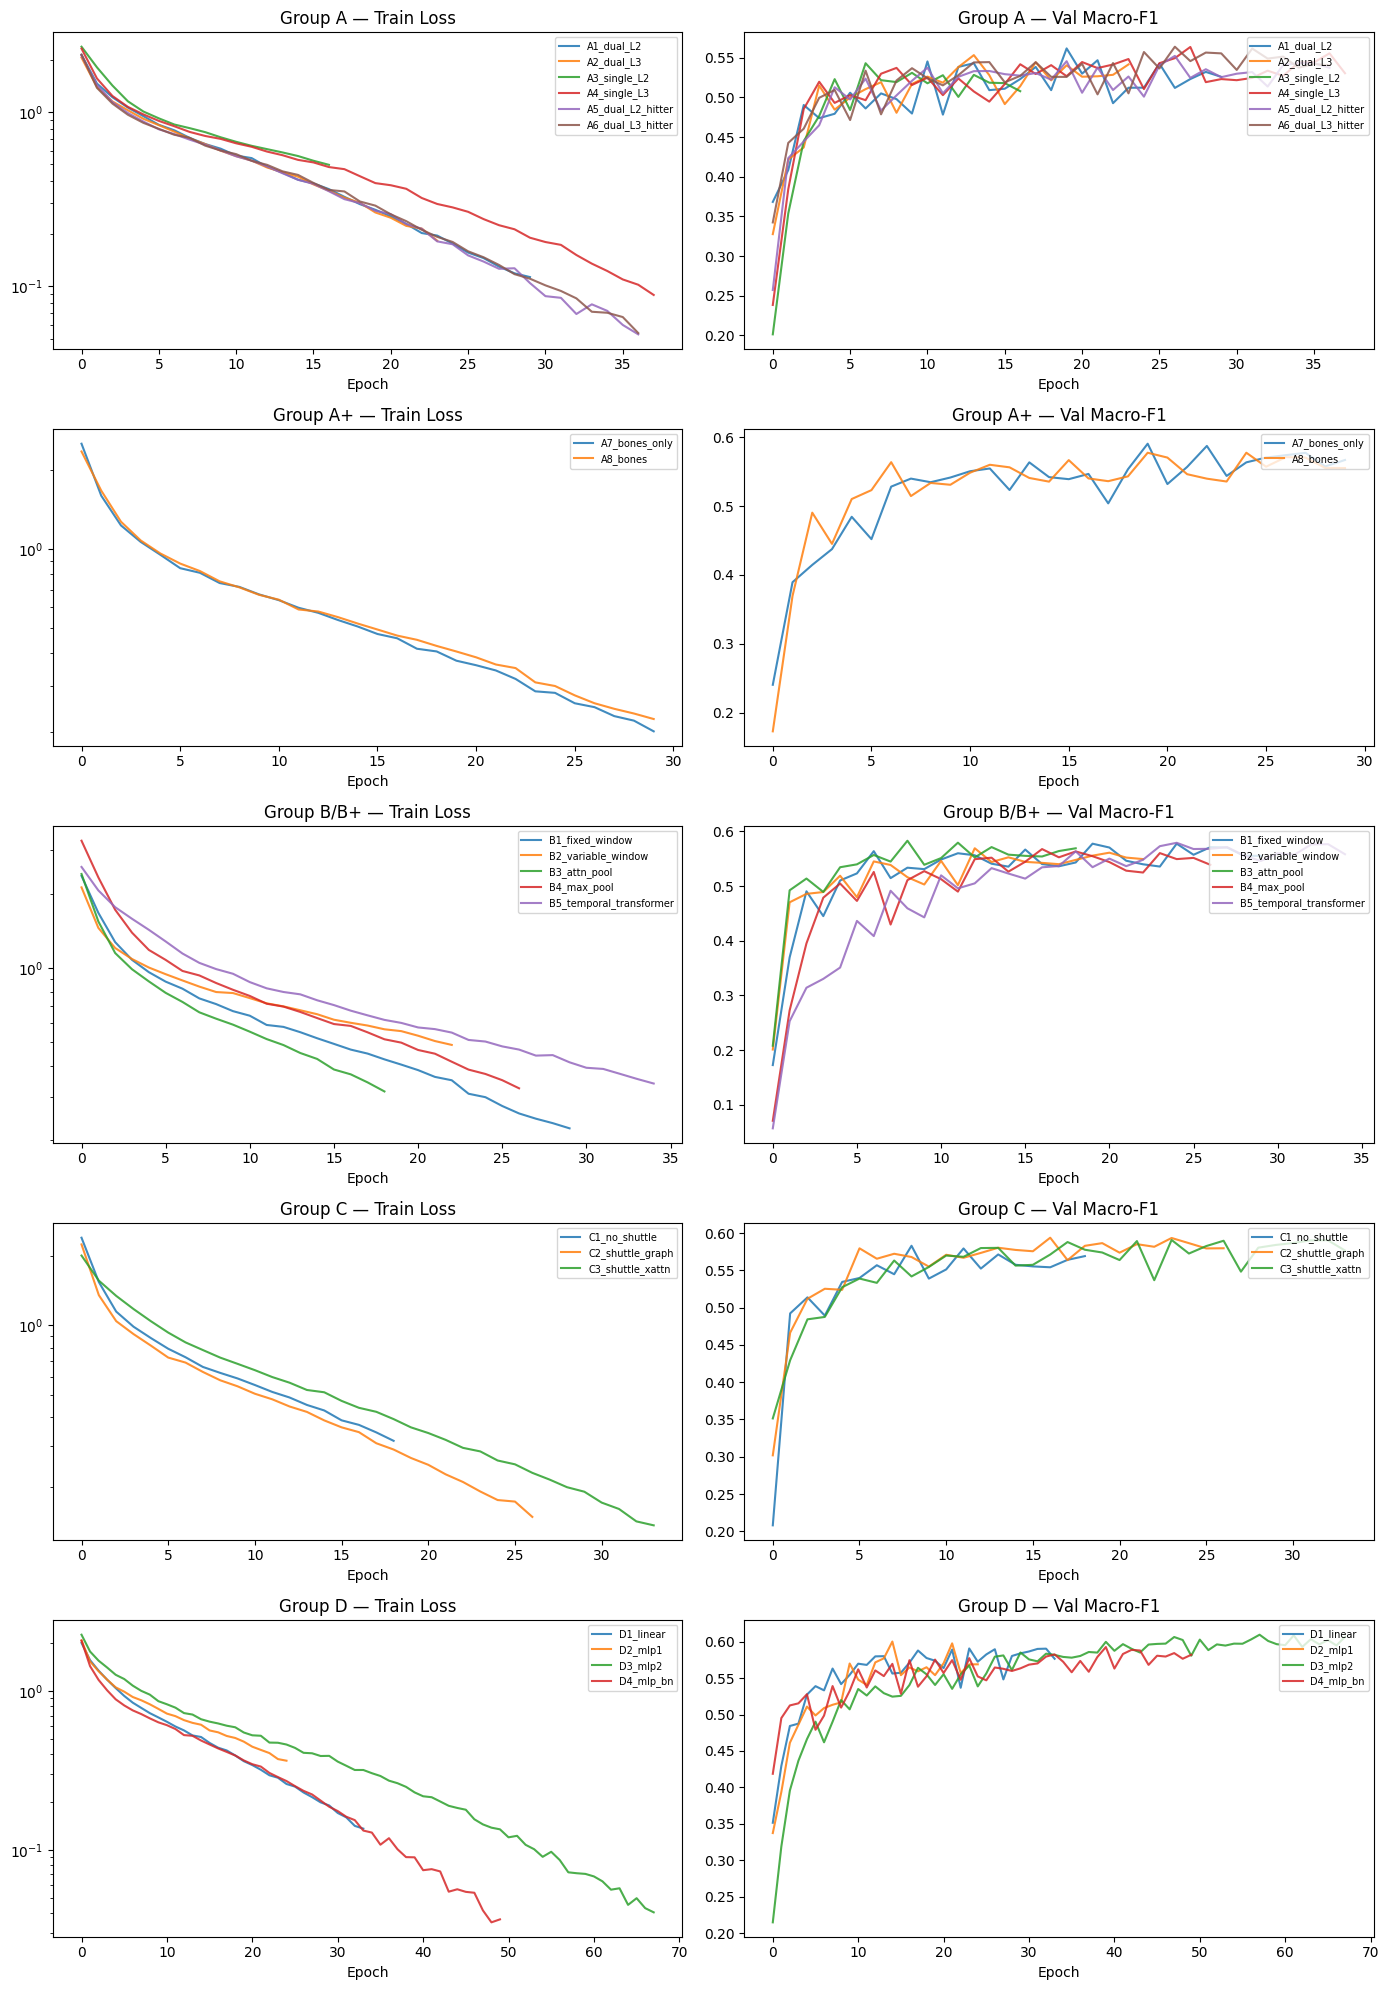

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/run6_training_curves.png


In [16]:
import matplotlib.pyplot as plt

# Training curves by group
_groups = [
    ('Group A',  ['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
                  'A5_dual_L2_hitter','A6_dual_L3_hitter']),
    ('Group A+', ['A7_bones_only','A8_bones','A9_bbox_norm','A10_bones_bbox']),
    ('Group B/B+',['B1_fixed_window','B2_variable_window','B3_attn_pool','B4_max_pool','B5_temporal_transformer']),
    ('Group C',  ['C1_no_shuttle','C2_shuttle_graph','C3_shuttle_xattn','C4_a1_xattn_ref']),
    ('Group D',  ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']),
]

fig, axes = plt.subplots(len(_groups), 2, figsize=(14, 4 * len(_groups)))
for row, (grp, names) in enumerate(_groups):
    for n in names:
        if n not in saved: continue
        r = saved[n]
        axes[row, 0].plot(r['history']['train_loss'], label=n, alpha=0.85)
        axes[row, 1].plot(r['history']['val_f1'],     label=n, alpha=0.85)
    axes[row, 0].set_title(f'{grp} — Train Loss'); axes[row, 0].set_yscale('log')
    axes[row, 1].set_title(f'{grp} — Val Macro-F1')
    for ax in axes[row]:
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlabel('Epoch')

plt.tight_layout()
out = ABLATION_DIR / 'run6_training_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

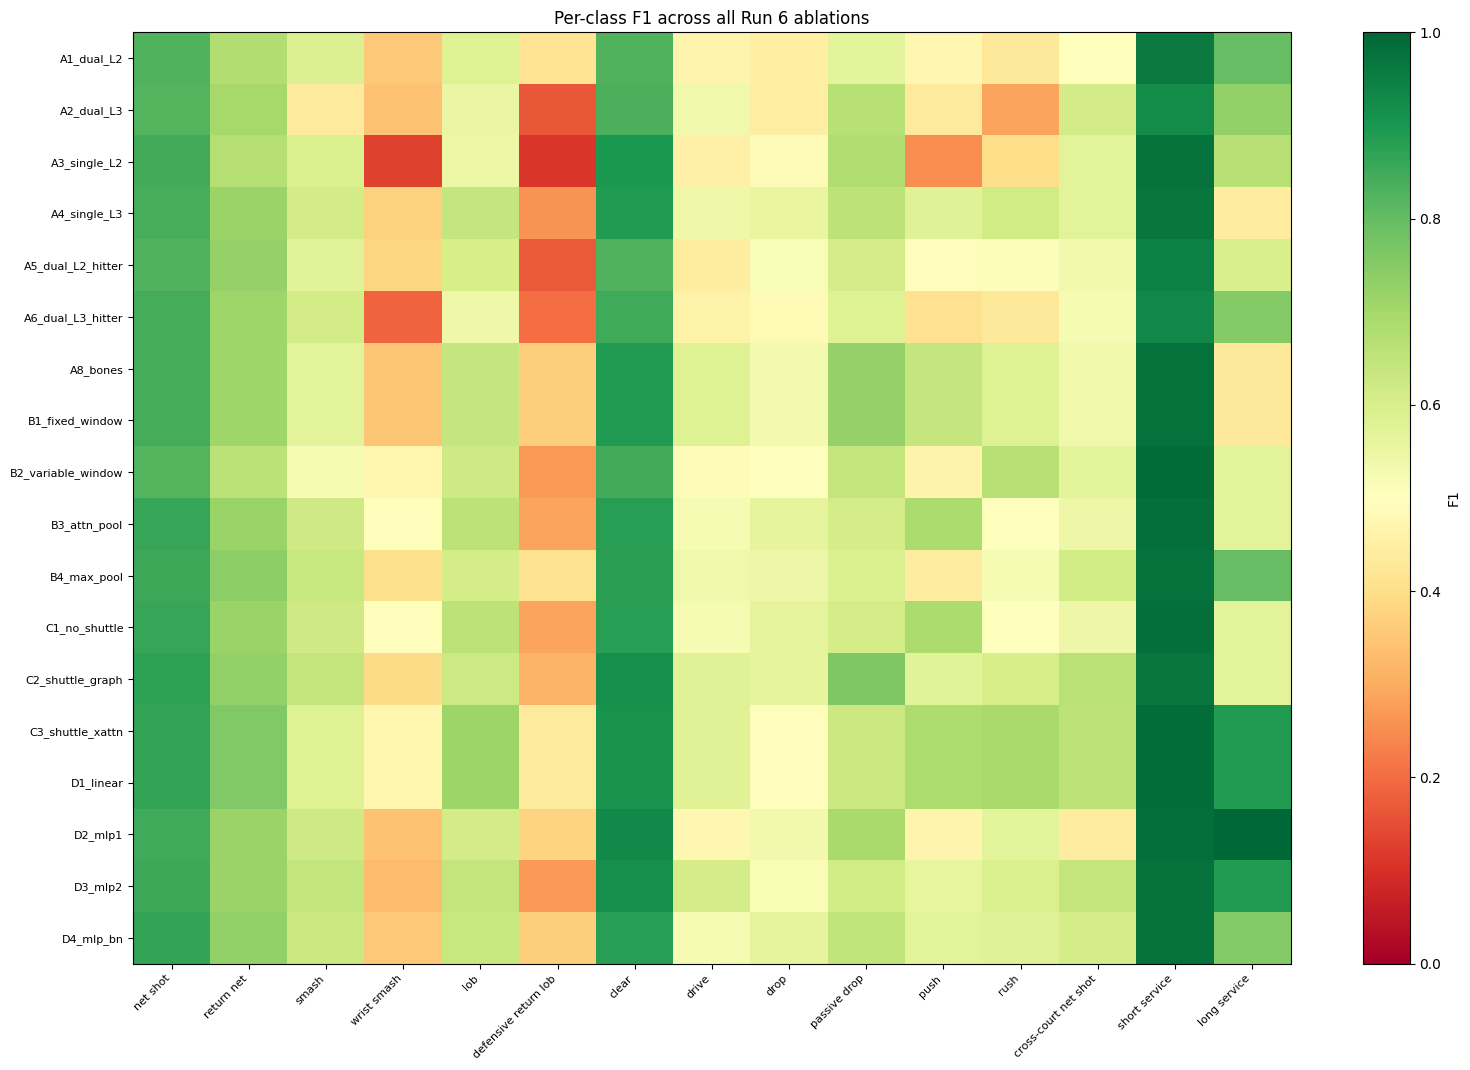

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/run6_perclass_heatmap.png


In [17]:
# Per-class F1 heatmap across all completed runs
names_in_order = [n for _, ns in _order for n in ns if n in saved and n != 'B1_fixed_window' or False]
names_in_order = list(dict.fromkeys(n for _, ns in _order for n in ns if n in saved))

matrix = []
for run_name in names_in_order:
    row = []
    pc  = saved[run_name]['per_class']
    for cls in SHOT_TYPES:
        row.append(pc.get(cls, {}).get('f1-score', 0.0))
    matrix.append(row)

fig, ax = plt.subplots(figsize=(16, max(6, len(names_in_order) * 0.6)))
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(SHOT_TYPES))); ax.set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(names_in_order))); ax.set_yticklabels(names_in_order, fontsize=8)
plt.colorbar(im, ax=ax, label='F1')
ax.set_title('Per-class F1 across all Run 6 ablations')
plt.tight_layout()
out2 = ABLATION_DIR / 'run6_perclass_heatmap.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

## §9 — Cross-Validation (Leave-2-Matches-Out)

CV on the 19 training-pool matches (2 held-out test matches fixed, never touched).
Each fold holds out 2 matches; remaining 17 train.

In [28]:
# ── §9 Reconfirm: read disk _final_config.json (the file CV will load) ────
import json as _json
_p  = ABLATION_DIR / '_final_config.json'
_fc = _json.loads(_p.read_text())
print('── §9: what CV will use (read from disk _final_config.json) ────────')
print(f'  ABLATION_DIR  = {ABLATION_DIR}')
print(f'  device        = {device}   SEED = {SEED}')
print(f'  EPOCHS={EPOCHS}  BATCH_SIZE={BATCH_SIZE}  LR={LR}  PATIENCE={PATIENCE}  SHOT_WINDOW={SHOT_WINDOW}')
print(f'  winner_name     = {_fc.get("winner_name")}')
print(f'  feature_layer   = {_fc.get("feature_layer")}     single_player = {_fc.get("single_player")}   use_hitter = {_fc.get("use_hitter")}')
print(f'  use_bones       = {_fc.get("use_bones")}   use_bbox_norm = {_fc.get("use_bbox_norm")}')
print(f'  pooling         = {_fc.get("pooling")}   variable_window = {_fc.get("variable_window")}')
print(f'  use_shuttle     = {_fc.get("use_shuttle")}   shuttle_fusion = {_fc.get("shuttle_fusion")}')

assert _fc.get('pooling') == 'attn', (
    f"Disk _final_config.json has pooling={_fc.get('pooling')!r}, expected 'attn'.\n"
    f"  → Patch it in Colab:\n"
    f"      _fc = json.loads(_p.read_text()); _fc['pooling']='attn'; _p.write_text(json.dumps(_fc,indent=2))"
)
print('  ✓ disk JSON has pooling=attn — CV will train attention-pooled')
print('────────────────────────────────────────────────────────────────────')

── §9: what CV will use (read from disk _final_config.json) ────────
  ABLATION_DIR  = /content/drive/MyDrive/Baddiev2/results/ablations/run7
  device        = cuda   SEED = 42
  EPOCHS=80  BATCH_SIZE=64  LR=0.001  PATIENCE=10  SHOT_WINDOW=32
  winner_name     = C3_shuttle_xattn
  feature_layer   = L3     single_player = True   use_hitter = False
  use_bones       = True   use_bbox_norm = False
  pooling         = attn   variable_window = False
  use_shuttle     = True   shuttle_fusion = cross_attn
  ✓ disk JSON has pooling=attn — CV will train attention-pooled
────────────────────────────────────────────────────────────────────


In [32]:
# ══════════════════════════════════════════════════════════════════════════
# §9 — Cross-Validation (Leave-2-Matches-Out) on C-winner
# ══════════════════════════════════════════════════════════════════════════
import time, numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader

class SinglePlayerCrossAttnWrapper(_Dataset):
    def __init__(self, ds):
        self.ds = ds; self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item     = self.ds[idx]
        x, label = item[0], item[1]
        shuttle  = item[2] if len(item) == 3 else torch.zeros(2, x.shape[1])
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label, shuttle


# 1. Build CV folds from the 19-match train pool
with open(SS_SPLIT_JSON) as f:
    _pool = sorted(json.load(f)['train'])
_shuf = list(_pool); np.random.RandomState(SEED).shuffle(_shuf)
CV_FOLDS = [(set(_shuf[i:i+2]), set(_pool) - set(_shuf[i:i+2]))
            for i in range(0, len(_shuf), 2)]
print(f'{len(CV_FOLDS)} folds | {len(_pool)} matches in pool')

# 2. Per-fold factory — fresh weights each call (NO leakage between folds)
def build_winner(tr_m, va_m):
    kw = dict(feature_layer=_fc['feature_layer'], use_hitter=_fc['use_hitter'],
              use_bones=_fc['use_bones'], use_bbox_norm=_fc['use_bbox_norm'],
              variable_window=_fc['variable_window'],
              use_shuttle=True, shuttle_fusion='cross_attn')
    tr = SinglePlayerCrossAttnWrapper(make_dataset(tr_m, **kw))
    va = SinglePlayerCrossAttnWrapper(make_dataset(va_m, **kw))
    in_ch = FEATURE_DIMS[_fc['feature_layer']] + (BONE_CHANNELS if _fc['use_bones'] else 0)
    enc = build_encoder(in_ch, num_nodes=NUM_JOINTS, pooling=_fc['pooling'])
    hd  = nn.Linear(256, N_CLASSES).to(device)
    ca  = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
    return tr, va, enc, hd, ca

# 3. Train one fold with early stopping
def train_fold(tr_ds, va_ds, enc, hd, ca):
    loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                        pin_memory=True, drop_last=True, collate_fn=collate_fn_shuttle)
    crit  = nn.CrossEntropyLoss(weight=compute_class_weights(tr_ds).to(device))
    params = list(enc.parameters()) + list(hd.parameters()) + list(ca.parameters())
    opt   = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    best_f1, no_imp = -1.0, 0
    for ep in range(EPOCHS):
        enc.train(); hd.train(); ca.train()
        for batch in loader:
            xb, yb = batch[0], batch[1]; valid = yb >= 0
            if not valid.any(): continue
            emb = ca(enc(xb[valid].to(device)), batch[2][valid].to(device))
            loss = crit(hd(emb), yb[valid].to(device))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        sched.step()
        f1, *_ = evaluate(enc, hd, va_ds, ca)
        if f1 > best_f1 + 1e-4: best_f1, no_imp = f1, 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE: break
    return best_f1

# 4. Run all folds
scores, t0 = [], time.time()
for fi, (va_m, tr_m) in enumerate(CV_FOLDS):
    torch.manual_seed(SEED + fi)
    f1 = train_fold(*build_winner(tr_m, va_m))
    scores.append(f1)
    print(f'Fold {fi+1}/{len(CV_FOLDS)} val={sorted(va_m)} → F1={f1:.4f}')

print(f'\nCV done in {(time.time()-t0)/60:.1f} min')
print(f'Mean F1: {np.mean(scores):.4f} ± {np.std(scores):.4f}  '
      f'(min {min(scores):.4f}, max {max(scores):.4f})')

# 5. Save
out = {_fc['winner_name']: {'scores': [round(s,4) for s in scores],
                            'mean':   round(float(np.mean(scores)),4),
                            'std':    round(float(np.std(scores)),4)},
       '_meta': {'n_folds': len(CV_FOLDS),
                 'folds':   [{'val': sorted(v), 'train_size': len(t)}
                             for v,t in CV_FOLDS]}}
with open(ABLATION_DIR / '_cv_results.json', 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved: {ABLATION_DIR}/_cv_results.json')


10 folds | 19 matches in pool
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15372 samples (14732 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2423 samples (2278 with labels)
Fold 1/10 val=['Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals', 'CHOU_Tien_Chen_Jonatan_CHRISTIE_Indonesia_Open_2019_Quarter-finals'] → F1=0.6097
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  16588 samples (15874 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1207 samples (1136 with labels)
Fold 2/10 val=['Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals', 'Viktor_AXELSEN _SHI_Yu_Qi_All_England_Open_2020_QuarterFinals'] → F1=0.6720
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  16171 samples (15423 with labels)
[INFO